In [ ]:
# ============================================================
# Discrimination Stability and Fairness Variability in
# Multi-Label ECG Classification: A Multi-Seed,
# External-Cohort Analysis — Full Pipeline
#
# Sudip Sharma et al. | Morgan State University, CEAMLS
#
# Trains four architectures (Baseline 1D-CNN, Mitigated 1D-CNN,
# Large 1D-CNN, Hybrid CNN-Transformer) on PTB-XL across ten
# random seeds; audits intersectional fairness under both FNR
# parity and equalized odds; tests whether cross-seed FNR
# instability survives per-run threshold calibration; formally
# tests whether FNR variance exceeds AUROC variance; explains
# predictions with 1D Grad-CAM; stress-tests robustness to
# clinical signal artifacts with an explicit SNR mapping; and
# externally validates all trained models, zero-shot, on the
# Georgia 12-Lead ECG Challenge Database.
#
# All trained weights are cached to Google Drive so the full
# study never retrains a model it has already trained.
# ============================================================

# %%
# ============================================================
# BLOCK 1: Dependencies
# ============================================================

import subprocess, sys

subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q",
     "wfdb", "pandas", "scikit-learn", "torch", "tqdm", "scipy"],
    check=True
)
print("Dependencies installed.")

Dependencies installed.


In [ ]:
# %%
# ============================================================
# BLOCK 2: Imports & Configuration
# ============================================================

import os, random, ast, time, glob, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.signal import find_peaks, resample as sp_resample
from scipy.stats import norm as sp_norm, levene

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.optim.lr_scheduler import ReduceLROnPlateau, CosineAnnealingLR, LinearLR, SequentialLR

from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import (roc_auc_score, f1_score, confusion_matrix,
                             brier_score_loss)
from sklearn.calibration import calibration_curve
from tqdm import tqdm
import wfdb

warnings.filterwarnings('ignore', category=DeprecationWarning)

# ----------------------------------------------------------
# Google Drive mount, ahead of any large download so a dropped
# Colab session never loses partial progress.
# ----------------------------------------------------------
from google.colab import drive
drive.mount('/content/drive')

PROJECT_DIR = '/content/drive/MyDrive/ecg_fairness_project'
os.makedirs(f'{PROJECT_DIR}/data', exist_ok=True)

# ----------------------------------------------------------
# Paths and class labels
# ----------------------------------------------------------
DATA_DIR = ('/content/fast_ptbxl/ptb-xl-a-large-publicly-available'
            '-electrocardiography-dataset-1.0.3')
CLASSES  = ['NORM', 'MI', 'STTC', 'CD', 'HYP']

# ----------------------------------------------------------
# Training hyper-parameters
# ----------------------------------------------------------
BATCH_SIZE      = 32
MAX_EPOCHS      = 60
PATIENCE_ES     = 7
PATIENCE_LR     = 3
LR_INIT         = 1e-3
LR_TRANSFORMER  = 1e-4
LR_FACTOR       = 0.5
LR_MIN          = 1e-5
WEIGHT_DECAY    = 1e-4

# ----------------------------------------------------------
# Ten fixed seed identifiers, chosen before any model was trained so no
# seed could later be dropped for looking unfavourable. A t-interval for
# the mean across these seeds is not itself an interval for their CV;
# CV uncertainty is handled separately by the checkpoint bootstrap in
# Block G.
SEEDS = [42, 123, 2026, 7, 99, 256, 512, 777, 2024, 31415]

# Model colour palette (used across all figures)
MODEL_COLORS = {
    'Baseline 1D-CNN':        '#e63946',
    'Mitigated 1D-CNN':       '#457b9d',
    'Large 1D-CNN':           '#f4a261',
    'Hybrid CNN-Transformer': '#1d3557',
}

# Global results store
results = {'single_run': {}, 'multi_run': {}}
training_times = {}


def set_global_seed(seed: int) -> None:
    """Set all random sources for reproducible training."""
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark     = False


set_global_seed(SEEDS[0])
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}  |  Max epochs: {MAX_EPOCHS}  |  Seeds: {len(SEEDS)}")

Mounted at /content/drive
Device: cuda  |  Max epochs: 60  |  Seeds: 10


In [ ]:
# %%
# ============================================================
# BLOCK 3: Data Acquisition
#
# The zip is downloaded onto Google Drive rather than local Colab
# storage, so a dropped session resumes an in-progress download
# instead of restarting it. Extraction happens on local disk for
# fast per-file read throughput during training.
# ============================================================

ZIP_NAME       = 'ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3.zip'
DRIVE_ZIP_PATH = f'{PROJECT_DIR}/data/{ZIP_NAME}'
ZIP_URL        = f'https://physionet.org/static/published-projects/ptb-xl/{ZIP_NAME}'

if os.path.exists(DATA_DIR):
    print(f"Dataset already extracted at: {DATA_DIR}")
else:
    print("Downloading PTB-XL to Google Drive...")
    subprocess.run(
        ["wget", "-c", "--tries=0", "--timeout=30",
         "--progress=bar:force:noscroll",
         "-O", DRIVE_ZIP_PATH, ZIP_URL],
        check=True
    )
    print("Extracting to local disk...")
    subprocess.run(
        ["unzip", "-q", "-o", DRIVE_ZIP_PATH, "-d", "/content/fast_ptbxl/"],
        check=True
    )
    assert os.path.exists(DATA_DIR), f"Extraction failed. Expected: {DATA_DIR}"
    print(f"Dataset ready: {DATA_DIR}")

Extracting to local disk...
Dataset ready: /content/fast_ptbxl/ptb-xl-a-large-publicly-available-electrocardiography-dataset-1.0.3


In [ ]:
# %%
# ============================================================
# BLOCK 4: Preprocessing & Official Train / Val / Test Split
#
# SCP codes are mapped to five diagnostic superclasses following
# Strodthoff et al. (2021). Official stratified 10-fold split:
#   Folds 1-8  -> Train  (n ~ 17,441)
#   Fold  9    -> Val    (n ~  2,186)
#   Fold  10   -> Test   (n ~  2,210)   held-out, never seen during training
# ============================================================

df     = pd.read_csv(f'{DATA_DIR}/ptbxl_database.csv', index_col='ecg_id')
agg_df = pd.read_csv(f'{DATA_DIR}/scp_statements.csv', index_col=0)
agg_df = agg_df[agg_df.diagnostic == 1.0]
df['scp_codes'] = df['scp_codes'].apply(ast.literal_eval)


def aggregate_diagnostic(y_dic: dict) -> list:
    """Map SCP codes to PTB-XL diagnostic superclasses."""
    out = []
    for code in y_dic:
        if code in agg_df.index:
            cls = agg_df.loc[code, 'diagnostic_class']
            if pd.notna(cls):
                out.append(cls)
    return list(set(out))


df['super_classes'] = df['scp_codes'].apply(aggregate_diagnostic)

mlb            = MultiLabelBinarizer(classes=CLASSES)
encoded_labels = mlb.fit_transform(df['super_classes'])
for i, c in enumerate(CLASSES):
    df[f'label_{c}'] = encoded_labels[:, i]

train_df = df[df.strat_fold <= 8]
val_df   = df[df.strat_fold == 9]
test_df  = df[df.strat_fold == 10]

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}  |  Test: {len(test_df):,}")
print("\nTraining set class prevalence:")
for c in CLASSES:
    print(f"  {c}: {int(train_df[f'label_{c}'].sum()):,}")

Train: 17,418  |  Val: 2,183  |  Test: 2,198

Training set class prevalence:
  NORM: 7,596
  MI: 4,379
  STTC: 4,186
  CD: 3,907
  HYP: 2,119


In [ ]:
# %%
# ============================================================
# BLOCK 5: Dataset, DataLoaders & Class-Frequency Weights
# ============================================================

class PTBXLDataset(Dataset):
    """
    Streaming loader for PTB-XL 100 Hz recordings.
    Per-lead z-score normalisation applied at read time.
    Returns (signal [12x1000], label [5], metadata dict).
    """
    def __init__(self, df: pd.DataFrame, data_dir: str, class_names: list):
        self.df       = df
        self.data_dir = data_dir
        self.labels   = df[[f'label_{c}' for c in class_names]].values.astype(np.float32)
        self.sex      = df['sex'].fillna(-1).values.astype(np.float32)
        self.age      = df['age'].fillna(df['age'].median()).values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        path      = f"{self.data_dir}/{self.df.iloc[idx]['filename_lr']}"
        signal, _ = wfdb.rdsamp(path)
        signal    = signal.T
        mu        = signal.mean(axis=1, keepdims=True)
        sigma     = signal.std(axis=1, keepdims=True)
        signal    = (signal - mu) / (sigma + 1e-8)
        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            {'sex': self.sex[idx], 'age': self.age[idx], 'ecg_id': self.df.index[idx]},
        )


train_dataset = PTBXLDataset(train_df, DATA_DIR, CLASSES)
val_dataset   = PTBXLDataset(val_df,   DATA_DIR, CLASSES)
test_dataset  = PTBXLDataset(test_df,  DATA_DIR, CLASSES)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=0, pin_memory=False)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=0, pin_memory=False)

_train_labels = train_df[[f'label_{c}' for c in CLASSES]].values.astype(float)
_N            = float(len(_train_labels))
_pos          = _train_labels.sum(axis=0)
pos_weights   = torch.tensor((_N - _pos) / _pos, dtype=torch.float32)

print("Positive weights (Mitigated CNN):")
for c, w in zip(CLASSES, pos_weights.tolist()):
    print(f"  {c}: {w:.2f}")

for x, y, _ in train_loader:
    print(f"\nBatch shape — Signal: {x.shape}  Labels: {y.shape}")
    break

Positive weights (Mitigated CNN):
  NORM: 1.29
  MI: 2.98
  STTC: 3.16
  CD: 3.46
  HYP: 7.22

Batch shape — Signal: torch.Size([32, 12, 1000])  Labels: torch.Size([32, 5])


In [ ]:
# %%
# ============================================================
# BLOCK 6: Model Architectures
#
#   A. ECG_1D_CNN       (~47K)   Baseline and Mitigated CNN
#   B. ECG_Large_CNN    (~479K)  Parameter-matched capacity ablation
#   C. Hybrid_ECG_Transformer  (~313K)  CNN encoder + 2-layer Transformer
# ============================================================

class ECG_1D_CNN(nn.Module):
    """
    Three-block 1D-CNN (~47K parameters).
    features[8] is the last Conv1d and the Grad-CAM target layer.
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12, 32, 7, padding=3),  nn.BatchNorm1d(32),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 5, padding=2),  nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))


class ECG_Large_CNN(nn.Module):
    """
    Five-block 1D-CNN (~479K parameters).
    Parameter-matched to the Hybrid Transformer; disentangles the
    effect of self-attention from raw model capacity.
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv1d(12,  64,  7, padding=3), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64,  128, 5, padding=2), nn.BatchNorm1d(128), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(128, 256, 5, padding=2), nn.BatchNorm1d(256), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(256, 224, 3, padding=1), nn.BatchNorm1d(224), nn.ReLU(),
            nn.Conv1d(224, 128, 3, padding=1), nn.BatchNorm1d(128), nn.ReLU(),
            nn.AdaptiveAvgPool1d(1),
        )
        self.classifier = nn.Sequential(
            nn.Linear(128, 64), nn.ReLU(), nn.Dropout(0.5), nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x).squeeze(-1))


class Hybrid_ECG_Transformer(nn.Module):
    """
    Strided CNN compresses (12, 1000) -> (128, 125); a 2-layer
    TransformerEncoder with 4-head attention then models inter-beat
    temporal context. (~313K parameters)
    """
    def __init__(self, num_classes: int = 5):
        super().__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(12, 64, 7, stride=2, padding=3), nn.BatchNorm1d(64),  nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(64, 128, 5, stride=2, padding=2),nn.BatchNorm1d(128), nn.ReLU(),
        )
        encoder_layer    = nn.TransformerEncoderLayer(
            d_model=128, nhead=4, dim_feedforward=256, dropout=0.3, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=2)
        self.classifier  = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.cnn(x).permute(0, 2, 1)
        x = self.transformer(x).mean(dim=1)
        return self.classifier(x)


print("Architecture summary:")
for name, arch in [("Baseline / Mitigated 1D-CNN",    ECG_1D_CNN()),
                   ("Large 1D-CNN (capacity ablation)", ECG_Large_CNN()),
                   ("Hybrid CNN-Transformer",            Hybrid_ECG_Transformer())]:
    n = sum(p.numel() for p in arch.parameters() if p.requires_grad)
    print(f"  {name:<42}: {n:>7,} params")

Architecture summary:
  Baseline / Mitigated 1D-CNN               :  46,757 params
  Large 1D-CNN (capacity ablation)          : 479,205 params
  Hybrid CNN-Transformer                    : 312,517 params


In [ ]:
# %%
# ============================================================
# BLOCK 7: Early Stopping & Training
#
# Both training loops always restore the best-validation-loss
# weights before returning a model, regardless of whether early
# stopping's own patience threshold was actually reached. A run
# that uses its full epoch budget without early stopping ever
# triggering therefore still returns the best epoch's weights,
# not simply the last one -- kept consistent across both the
# shared CNN loop and the Transformer's warmup+cosine loop.
# ============================================================

class EarlyStopping:
    """Stop training and restore best weights when val loss plateaus."""
    def __init__(self, patience: int = PATIENCE_ES, min_delta: float = 1e-4):
        self.patience     = patience
        self.min_delta    = min_delta
        self.best_loss    = float('inf')
        self.counter      = 0
        self.best_weights = None
        self.triggered    = False

    def step(self, val_loss: float, model: nn.Module) -> bool:
        if val_loss < self.best_loss - self.min_delta:
            self.best_loss    = val_loss
            self.counter      = 0
            self.best_weights = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            self.counter += 1
            if self.counter >= self.patience:
                if self.best_weights:
                    model.load_state_dict(self.best_weights)
                self.triggered = True
        return self.triggered


def _training_loop(model, train_loader, val_loader, criterion,
                   max_epochs, lr, label):
    """Shared loop returning (model, history). Used by the Baseline,
    Mitigated, and Large CNN variants (they differ only in loss
    function and/or capacity, not in optimiser/scheduler)."""
    model     = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=LR_FACTOR,
                                  patience=PATIENCE_LR, min_lr=LR_MIN)
    stopper   = EarlyStopping()
    history   = {'train_loss': [], 'val_loss': [], 'n_epochs': 0}

    for epoch in range(1, max_epochs + 1):
        model.train()
        t_loss = 0.0
        for x, y, _ in tqdm(train_loader, desc=f"[{label}] Epoch {epoch:03d} Train",
                             leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, y, _ in tqdm(val_loader, desc=f"[{label}] Epoch {epoch:03d} Val  ",
                                 leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                v_loss += criterion(model(x), y).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step(avg_v)
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['n_epochs'] = epoch

        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{max_epochs}  train {avg_t:.4f}  val {avg_v:.4f}  lr {lr_now:.2e}")

        if stopper.step(avg_v, model):
            print(f"Early stopping at epoch {epoch} (best val {stopper.best_loss:.4f}).")
            break

    # Ensure the returned model always reflects the best validation
    # loss seen, even if the loop reached max_epochs without early
    # stopping ever triggering the restoration inside stopper.step().
    if stopper.best_weights is not None:
        model.load_state_dict(stopper.best_weights)
    return model, history


def train_model(model, train_loader, val_loader,
                 max_epochs=MAX_EPOCHS, lr=LR_INIT):
    """Standard (unweighted BCE) training for the Baseline and Large CNNs."""
    return _training_loop(model, train_loader, val_loader,
                          nn.BCEWithLogitsLoss(), max_epochs, lr,
                          label=type(model).__name__)


def train_mitigated_model(model, train_loader, val_loader, pos_weights,
                           max_epochs=MAX_EPOCHS, lr=LR_INIT):
    """Class-frequency-weighted BCE training for the Mitigated CNN."""
    return _training_loop(model, train_loader, val_loader,
                          nn.BCEWithLogitsLoss(pos_weight=pos_weights.to(DEVICE)),
                          max_epochs, lr, label="Mitigated")


def train_transformer_model(model, train_loader, val_loader,
                             max_epochs=MAX_EPOCHS, lr=3e-4,
                             warmup_epochs=5):
    """Warmup + cosine decay schedule with gradient clipping, used for
    the Hybrid CNN-Transformer in both the single-run (Block 11) and
    multi-run (Block 12) analyses -- the CNN variants train under the
    plateau schedule in _training_loop instead."""
    model     = model.to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=lr,
                            weight_decay=WEIGHT_DECAY)

    warmup_scheduler = LinearLR(optimizer, start_factor=0.05,
                                 end_factor=1.0, total_iters=warmup_epochs)
    cosine_scheduler = CosineAnnealingLR(optimizer,
                                          T_max=max_epochs - warmup_epochs,
                                          eta_min=LR_MIN)
    scheduler = SequentialLR(optimizer,
                              schedulers=[warmup_scheduler, cosine_scheduler],
                              milestones=[warmup_epochs])
    stopper   = EarlyStopping(patience=PATIENCE_ES)
    history   = {'train_loss': [], 'val_loss': [], 'n_epochs': 0}
    criterion = nn.BCEWithLogitsLoss()

    for epoch in range(1, max_epochs + 1):
        model.train()
        t_loss = 0.0
        for x, y, _ in tqdm(train_loader,
                             desc=f"[Transformer] Epoch {epoch:03d} Train",
                             leave=False):
            x, y = x.to(DEVICE), y.to(DEVICE)
            optimizer.zero_grad()
            loss = criterion(model(x), y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for x, y, _ in tqdm(val_loader,
                                 desc=f"[Transformer] Epoch {epoch:03d} Val  ",
                                 leave=False):
                x, y = x.to(DEVICE), y.to(DEVICE)
                v_loss += criterion(model(x), y).item()

        avg_t = t_loss / len(train_loader)
        avg_v = v_loss / len(val_loader)
        scheduler.step()
        history['train_loss'].append(avg_t)
        history['val_loss'].append(avg_v)
        history['n_epochs'] = epoch

        lr_now = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d}/{max_epochs}  train {avg_t:.4f}  "
              f"val {avg_v:.4f}  lr {lr_now:.2e}")

        if stopper.step(avg_v, model):
            print(f"Early stopping at epoch {epoch} "
                  f"(best val {stopper.best_loss:.4f}).")
            break

    if stopper.best_weights is not None:
        model.load_state_dict(stopper.best_weights)
    return model, history


In [ ]:
# %%
# ============================================================
# BLOCK 8: Subgroup Definitions & Inference
# ============================================================

SUBGROUPS = {
    'Young Male (<60)':   lambda s, a: (s == 0) & (a <  60),
    'Older Male (60+)':   lambda s, a: (s == 0) & (a >= 60),
    'Young Female (<60)': lambda s, a: (s == 1) & (a <  60),
    'Older Female (60+)': lambda s, a: (s == 1) & (a >= 60),
}


def get_predictions(model: nn.Module, loader: DataLoader) -> dict:
    """Run inference and return probs, preds (tau=0.5), targets, and metadata."""
    model.eval()
    probs_all, targets_all, sex_all, age_all = [], [], [], []

    with torch.no_grad():
        for x, y, meta in loader:
            p = torch.sigmoid(model(x.to(DEVICE))).cpu().numpy()
            probs_all.extend(p)
            targets_all.extend(y.numpy())
            sex_all.extend(meta['sex'].numpy())
            age_all.extend(meta['age'].numpy())

    probs = np.array(probs_all)
    return {
        'probs':   probs,
        'preds':   (probs > 0.5).astype(int),
        'targets': np.array(targets_all),
        'sex':     np.array(sex_all),
        'age':     np.array(age_all),
    }


def apply_thresholds(pred_dict: dict, thresholds: np.ndarray) -> dict:
    """
    Return a copy of pred_dict with class predictions recomputed at
    the given per-class thresholds instead of the fixed tau=0.5
    cutoff baked into get_predictions.
    """
    out = dict(pred_dict)
    out['preds'] = (pred_dict['probs'] > thresholds[np.newaxis, :]).astype(int)
    return out


def select_thresholds(model: nn.Module, loader: DataLoader,
                       grid: np.ndarray = np.linspace(0.05, 0.95, 19)) -> np.ndarray:
    """
    Per-class decision threshold maximising F1 on the validation
    set, selected independently of the held-out test fold. Used to
    test whether cross-seed FNR variability reflects genuine
    representational instability or is driven by per-run
    probability-calibration drift interacting with a fixed 0.5
    cutoff.
    """
    pd_ = get_predictions(model, loader)
    thresholds = np.full(len(CLASSES), 0.5)
    for i in range(len(CLASSES)):
        probs, targets = pd_['probs'][:, i], pd_['targets'][:, i]
        if targets.sum() == 0:
            continue
        f1s = [f1_score(targets, (probs > t).astype(int), zero_division=0) for t in grid]
        thresholds[i] = grid[int(np.argmax(f1s))]
    return thresholds

In [ ]:
# %%
# ============================================================
# BLOCK 9: Evaluation & Fairness Audit Functions
# ============================================================

def safe_macro_auroc(targets, probs):
    targets, probs = np.asarray(targets), np.asarray(probs)
    if targets.shape != probs.shape or targets.ndim != 2:
        raise ValueError("Targets and probabilities must have matching [records, classes] shapes.")
    if not np.isfinite(probs).all():
        raise ValueError("Nonfinite model probabilities: inspect input signals/checkpoint.")
    if not np.isin(targets, [0, 1]).all():
        raise ValueError("Expected binary multilabel targets.")
    if any(np.unique(targets[:, j]).size != 2 for j in range(targets.shape[1])):
        return float('nan')  # Preserve the fixed class set, never average a different subset.
    return float(roc_auc_score(targets, probs, average='macro'))


def compute_overall_metrics(pred_dict: dict) -> dict:
    auroc = safe_macro_auroc(pred_dict['targets'], pred_dict['probs'])
    if not np.isfinite(auroc):
        warnings.warn("Macro-AUROC undefined: at least one class has no positives or no negatives.")
    f1 = f1_score(pred_dict['targets'], pred_dict['preds'], average='macro', zero_division=0)
    return {'auroc': auroc, 'f1': f1}


def bootstrap_metric_ci(pred_dict: dict, metric: str = 'auroc',
                         n_boot: int = 1000, seed: int = 0) -> tuple:
    """Record bootstrap, not patient bootstrap. Fixed class set in every resample.
    AUROC intervals exclude undefined resamples and report how many were valid.
    If >5% are invalid, withhold the interval; this is a reporting guard, not
    a guarantee of coverage for rare labels. Patient inference is in Block G.
    """
    if metric not in ('auroc', 'f1'):
        raise ValueError(metric)
    if metric == 'auroc' and not np.isfinite(safe_macro_auroc(pred_dict['targets'], pred_dict['probs'])):
        print('AUROC CI undefined in the original sample; no interval reported.')
        return (np.nan, np.nan)
    rng = np.random.default_rng(seed)
    n = len(pred_dict['targets']); vals = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        if metric == 'auroc':
            value = safe_macro_auroc(pred_dict['targets'][idx], pred_dict['probs'][idx])
        else:
            value = f1_score(pred_dict['targets'][idx], pred_dict['preds'][idx],
                             average='macro', zero_division=0)
        if np.isfinite(value): vals.append(value)
    print(f'{metric} record-bootstrap CI: {len(vals)}/{n_boot} valid resamples.')
    if len(vals) < max(2, int(np.ceil(.95*n_boot))):
        warnings.warn('Too many undefined resamples; CI withheld.')
        return (np.nan, np.nan)
    return tuple(np.percentile(vals, [2.5, 97.5]))


def bootstrap_fnr_ci(targets: np.ndarray, preds: np.ndarray,
                     n_boot: int = 1000, seed: int = 0) -> tuple:
    """Percentile bootstrap 95% CI for FNR = FN / (FN + TP)."""
    if targets.sum() < 5:
        return (np.nan, np.nan)
    rng      = np.random.default_rng(seed)
    n        = len(targets)
    fnr_boot = []
    for _ in range(n_boot):
        idx  = rng.choice(n, size=n, replace=True)
        t, p = targets[idx], preds[idx]
        if t.sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(t, p, labels=[0, 1]).ravel()
        fnr_boot.append(fn / max(fn + tp, 1))
    if not fnr_boot:
        return (np.nan, np.nan)
    return (np.percentile(fnr_boot, 2.5), np.percentile(fnr_boot, 97.5))


def bootstrap_fpr_ci(targets: np.ndarray, preds: np.ndarray,
                     n_boot: int = 1000, seed: int = 0) -> tuple:
    """Percentile bootstrap 95% CI for FPR = FP / (FP + TN)."""
    if (targets == 0).sum() < 5:
        return (np.nan, np.nan)
    rng      = np.random.default_rng(seed)
    n        = len(targets)
    fpr_boot = []
    for _ in range(n_boot):
        idx  = rng.choice(n, size=n, replace=True)
        t, p = targets[idx], preds[idx]
        if (t == 0).sum() == 0:
            continue
        tn, fp, fn, tp = confusion_matrix(t, p, labels=[0, 1]).ravel()
        fpr_boot.append(fp / max(fp + tn, 1))
    if not fpr_boot:
        return (np.nan, np.nan)
    return (np.percentile(fpr_boot, 2.5), np.percentile(fpr_boot, 97.5))


def compute_fnr_by_group(pred_dict: dict, with_ci: bool = False) -> dict:
    """FNR_k,g = FN_k,g / (FN_k,g + TP_k,g) per class per subgroup."""
    sex, age = pred_dict['sex'], pred_dict['age']
    out      = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            gt   = pred_dict['targets'][mask, i]
            pr   = pred_dict['preds'][mask, i]
            if gt.sum() == 0:
                out[cls][gname] = (None, np.nan, np.nan) if with_ci else None
                continue
            tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
            fnr = fn / max(fn + tp, 1)
            if with_ci:
                lo, hi = bootstrap_fnr_ci(gt, pr)
                out[cls][gname] = (fnr, lo, hi)
            else:
                out[cls][gname] = fnr
    return out


def compute_fpr_by_group(pred_dict: dict, with_ci: bool = False) -> dict:
    """
    FPR_k,g = FP_k,g / (FP_k,g + TN_k,g) per class per subgroup.
    FNR parity alone (equality of opportunity) can miss disparities
    that surface only in the false-positive rate; equalized odds
    (Hardt et al., 2016) requires both to be checked.
    """
    sex, age = pred_dict['sex'], pred_dict['age']
    out      = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            gt   = pred_dict['targets'][mask, i]
            pr   = pred_dict['preds'][mask, i]
            if (gt == 0).sum() == 0:
                out[cls][gname] = (None, np.nan, np.nan) if with_ci else None
                continue
            tn, fp, fn, tp = confusion_matrix(gt, pr, labels=[0, 1]).ravel()
            fpr = fp / max(fp + tn, 1)
            if with_ci:
                lo, hi = bootstrap_fpr_ci(gt, pr)
                out[cls][gname] = (fpr, lo, hi)
            else:
                out[cls][gname] = fpr
    return out


def compute_fnr_disparity(rate_dict: dict) -> dict:
    """
    Disparity = max subgroup rate − min subgroup rate per class.
    Operates on any per-subgroup rate dictionary shaped like the
    output of compute_fnr_by_group or compute_fpr_by_group.
    """
    out = {}
    for cls in CLASSES:
        vals = []
        for v in rate_dict[cls].values():
            scalar = v[0] if isinstance(v, tuple) else v
            if scalar is not None:
                vals.append(scalar)
        out[cls] = (max(vals) - min(vals)) if len(vals) >= 2 else None
    return out


def compute_equalized_odds_gap(fnr_dict: dict, fpr_dict: dict) -> dict:
    """
    Equalized-odds gap per class (Hardt et al., 2016): equalized
    odds requires equal FNR *and* equal FPR across subgroups, so the
    binding constraint is whichever disparity is larger.
    """
    fnr_disp = compute_fnr_disparity(fnr_dict)
    fpr_disp = compute_fnr_disparity(fpr_dict)
    out = {}
    for cls in CLASSES:
        vals = [v for v in (fnr_disp.get(cls), fpr_disp.get(cls)) if v is not None]
        out[cls] = max(vals) if vals else None
    return out


def compute_subgroup_counts(pred_dict: dict) -> dict:
    """
    Positive case count (TP + FN) per class per subgroup — the
    denominator underlying every FNR estimate and its bootstrap CI.
    """
    sex, age = pred_dict['sex'], pred_dict['age']
    out = {}
    for i, cls in enumerate(CLASSES):
        out[cls] = {}
        for gname, mask_fn in SUBGROUPS.items():
            mask = mask_fn(sex, age)
            out[cls][gname] = int(pred_dict['targets'][mask, i].sum())
    return out


def compute_brier_scores(pred_dict: dict) -> dict:
    """Per-class and macro-averaged Brier score."""
    scores = {}
    for i, cls in enumerate(CLASSES):
        scores[cls] = brier_score_loss(pred_dict['targets'][:, i],
                                        pred_dict['probs'][:, i])
    scores['macro'] = float(np.mean([scores[c] for c in CLASSES]))
    return scores


# ----------------------------------------------------------
# DeLong (1988) AUROC comparison test
# ----------------------------------------------------------

def _placement_values(pos_probs: np.ndarray, neg_probs: np.ndarray) -> tuple:
    """Structural components (V10, V01) for DeLong's variance estimator."""
    V10 = np.array([(pos_probs > n).mean() + 0.5 * (pos_probs == n).mean()
                    for n in neg_probs])
    V01 = np.array([(p > neg_probs).mean() + 0.5 * (p == neg_probs).mean()
                    for p in pos_probs])
    return V10, V01


def delong_test(targets: np.ndarray, probs_a: np.ndarray, probs_b: np.ndarray) -> tuple:
    """
    DeLong et al. (1988) two-sided test comparing two per-class
    AUROCs on the same test set. Returns
    (auroc_a, auroc_b, z_statistic, two_sided_p_value).
    """
    auroc_a = roc_auc_score(targets, probs_a)
    auroc_b = roc_auc_score(targets, probs_b)

    pos_idx = np.where(targets == 1)[0]
    neg_idx = np.where(targets == 0)[0]
    m, n    = len(pos_idx), len(neg_idx)
    if m < 2 or n < 2:
        return auroc_a, auroc_b, np.nan, np.nan

    V10_a, V01_a = _placement_values(probs_a[pos_idx], probs_a[neg_idx])
    V10_b, V01_b = _placement_values(probs_b[pos_idx], probs_b[neg_idx])

    var_a = np.var(V10_a, ddof=1) / n + np.var(V01_a, ddof=1) / m
    var_b = np.var(V10_b, ddof=1) / n + np.var(V01_b, ddof=1) / m
    cov   = (np.cov(V10_a, V10_b, ddof=1)[0, 1] / n +
             np.cov(V01_a, V01_b, ddof=1)[0, 1] / m)

    se = np.sqrt(max(var_a + var_b - 2 * cov, 1e-12))
    z  = (auroc_a - auroc_b) / se
    p  = 2 * sp_norm.sf(abs(z))
    return auroc_a, auroc_b, z, p


def run_delong_comparisons(baseline_name: str = 'Baseline 1D-CNN') -> None:
    """
    Per-class DeLong AUROC comparisons between the baseline and each
    other model. These compare per-class AUROC and are distinct from
    the macro-AUROC comparison in Table III: a per-class difference
    here does not imply the aggregate macro-AUROC differs.
    """
    baseline_pd = results['single_run'][baseline_name]['pred_dict']
    comparisons = {k: v['pred_dict'] for k, v in results['single_run'].items()
                   if k != baseline_name}

    print(f"\n{'='*75}")
    print(f"  DeLong AUROC Comparisons — {baseline_name} vs. each model")
    print(f"  Per-class AUROC; see Table III for macro-AUROC comparison")
    print(f"  * p<0.05   ** p<0.01   *** p<0.001  (Bonferroni α_adj = 0.01)")
    print(f"{'='*75}")
    header = f"  {'Class':<6}" + "".join(f"  {k:<28}" for k in comparisons)
    print(header)
    print(f"  {'-'*70}")

    for i, cls in enumerate(CLASSES):
        row = f"  {cls:<6}"
        for comp_name, comp_pd in comparisons.items():
            try:
                _, _, z, p = delong_test(
                    baseline_pd['targets'][:, i],
                    baseline_pd['probs'][:, i],
                    comp_pd['probs'][:, i]
                )
                stars = ('***' if p < 0.001 else '**' if p < 0.01
                         else '*' if p < 0.05 else 'ns')
                row  += f"  z={z:+.2f}  p={p:.3f} {stars:<4}"
            except Exception:
                row  += f"  {'N/A':<20}"
        print(row)
    print()


def calc_stats(data: list) -> tuple:
    """Mean, sample SD, 95% CI half-width via t-distribution."""
    arr          = np.array(data, dtype=float)
    mean         = arr.mean()
    std          = arr.std(ddof=1)
    ci_lo, ci_hi = stats.t.interval(0.95, df=len(arr) - 1,
                                     loc=mean, scale=stats.sem(arr))
    ci_half      = (ci_hi - ci_lo) / 2 if not np.isnan(ci_lo) else 0.0
    return mean, std, ci_half


def run_variance_test(auroc_runs: list, fnr_runs: list) -> tuple:
    """
    Brown-Forsythe (median-centred Levene) test comparing the
    relative dispersion of macro-AUROC to that of subgroup FNR
    across seeds. Each series is first divided by its own mean so
    that two metrics on different natural scales (a 0-1 ratio vs. a
    percentage) are compared as dimensionless relative variability,
    directly testing whether the coefficient-of-variation gap is
    statistically distinguishable from sampling noise rather than
    an artifact of comparing raw variances on different scales.
    """
    auroc_arr = np.array(auroc_runs)
    fnr_arr   = np.array(fnr_runs)
    auroc_rel = auroc_arr / auroc_arr.mean()
    fnr_rel   = fnr_arr / fnr_arr.mean()
    stat, p = levene(auroc_rel, fnr_rel, center='median')
    return stat, p


def relative_improvement(baseline: float, improved: float,
                          higher_is_better: bool = True) -> float:
    """Percentage change of `improved` relative to `baseline`."""
    if baseline == 0:
        return np.nan
    delta = improved - baseline
    return (delta / abs(baseline)) * 100 * (1 if higher_is_better else -1)


def print_fairness_report(model_name: str, fnr_dict: dict,
                           disparity: dict = None, counts: dict = None) -> None:
    """Print intersectional FNR report with bootstrap CIs, subgroup
    disparity, and the positive-case count each estimate rests on."""
    print(f"\n{'='*70}")
    print(f"  {model_name}  —  Intersectional Fairness Audit (Test Set, Fold 10)")
    print(f"  FNR = FN / (FN + TP)  |  95% CI via 1000-sample bootstrap")
    print(f"{'='*70}")
    for cls in CLASSES:
        disp_str = ""
        if disparity and disparity.get(cls) is not None:
            disp_str = f"  [disparity = {disparity[cls]*100:.1f}%]"
        print(f"\n  {cls}{disp_str}:")
        for gname, val in fnr_dict[cls].items():
            n_str = f"  (n={counts[cls][gname]} positive)" if counts is not None else ""
            if isinstance(val, tuple):
                fnr, lo, hi = val
                if fnr is None:
                    print(f"    {gname:<24} | N/A{n_str}")
                else:
                    print(f"    {gname:<24} | FNR = {fnr:.1%}  [95% CI: {lo:.1%}, {hi:.1%}]{n_str}")
            else:
                print(f"    {gname:<24} | {'N/A' if val is None else f'FNR = {val:.1%}'}{n_str}")
    print()


def print_equalized_odds_report(model_name: str, fnr_dict: dict, fpr_dict: dict) -> None:
    """Side-by-side FNR/FPR report per class per subgroup."""
    print(f"\n{'='*70}")
    print(f"  {model_name}  —  Equalized Odds Audit (Test Set, Fold 10)")
    print(f"{'='*70}")
    for cls in CLASSES:
        print(f"\n  {cls}:")
        for gname in SUBGROUPS:
            fnr_v = fnr_dict[cls].get(gname)
            fpr_v = fpr_dict[cls].get(gname)
            fnr_v = fnr_v[0] if isinstance(fnr_v, tuple) else fnr_v
            fpr_v = fpr_v[0] if isinstance(fpr_v, tuple) else fpr_v
            fnr_s = f"{fnr_v:.1%}" if fnr_v is not None else "N/A"
            fpr_s = f"{fpr_v:.1%}" if fpr_v is not None else "N/A"
            print(f"    {gname:<24} | FNR = {fnr_s:<8}  FPR = {fpr_s}")
    print()


def print_results_table() -> None:
    """Multi-run summary table."""
    n = len(SEEDS)
    print(f"\n{'='*90}")
    print(f"  Table 3: Multi-Run Classification Performance  (mean ± SD, {n} seeds)")
    print(f"{'='*90}")
    print(f"  {'Model':<28}  {'AUROC':<16}  {'F1':<16}  {'OF-MI FNR τ=0.5':<18}  "
          f"{'OF-MI FNR calib.':<18}  CV-FNR(τ)")
    print(f"  {'-'*86}")
    for mname, mdata in results['multi_run'].items():
        am, as_, aci = calc_stats(mdata['auroc'])
        fm, fs_, fci = calc_stats(mdata['f1'])
        nm, ns_, nci = calc_stats(mdata['fnr_fixed'])
        cm, cs_, cci = calc_stats(mdata['fnr_calibrated'])
        cv           = (ns_ / nm * 100) if nm > 0 else 0
        print(f"  {mname:<28}  "
              f"{am:.3f}±{as_:.3f}  "
              f"{fm:.3f}±{fs_:.3f}  "
              f"{nm:.1f}±{ns_:.1f}  "
              f"{cm:.1f}±{cs_:.1f}  "
              f"{cv:.1f}%")
    print()

In [ ]:
# %%
# ============================================================
# BLOCK 10: Checkpoint & Prediction Caching
#
# Caches model checkpoints and training history, plus raw
# predictions and selected thresholds, per (model, seed, split).
# Several downstream analyses need the same (model, seed)
# predictions more than once -- the multi-run stability loop, the
# patient-level bootstrap, and the matched-threshold comparison all
# evaluate the same checkpoints -- so caching to disk once avoids
# re-running inference for each of them.
# ============================================================

import json, hashlib
from torch.utils.data import SequentialSampler

# All 40 checkpoints already exist, so this stays True: a fresh run
# only reloads and re-evaluates them, and never retrains anything.
ANALYSIS_ONLY = True

CHECKPOINT_DIR = f'{PROJECT_DIR}/checkpoints'
SAVE_DIR       = f'{PROJECT_DIR}/figures/'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)


def _checkpoint_path(model_name: str, seed: int) -> str:
    safe_name = model_name.replace(' ', '_').replace('/', '-')
    return os.path.join(CHECKPOINT_DIR, f"{safe_name}_seed{seed}.pth")


def _history_path(model_name: str, seed: int) -> str:
    safe_name = model_name.replace(' ', '_').replace('/', '-')
    return os.path.join(CHECKPOINT_DIR, f"{safe_name}_seed{seed}_history.json")


def save_checkpoint(model: nn.Module, model_name: str, seed: int) -> None:
    torch.save(model.state_dict(), _checkpoint_path(model_name, seed))
    print(f"  Checkpoint saved: {model_name} (seed {seed})")


def load_checkpoint(model: nn.Module, model_name: str, seed: int) -> nn.Module:
    state = torch.load(_checkpoint_path(model_name, seed), map_location=DEVICE)
    model.load_state_dict(state)
    model._checkpoint_sha256 = _file_sha256(_checkpoint_path(model_name, seed))
    return model.to(DEVICE)


def checkpoint_exists(model_name: str, seed: int) -> bool:
    return os.path.exists(_checkpoint_path(model_name, seed))


def save_history(history: dict, model_name: str, seed: int) -> None:
    with open(_history_path(model_name, seed), 'w') as f:
        json.dump(history, f)


def load_history(model_name: str, seed: int):
    path = _history_path(model_name, seed)
    return json.load(open(path)) if os.path.exists(path) else None


def train_or_load(model_class, model_name: str, seed: int,
                   train_fn, train_kwargs: dict, num_classes: int = 5):
    """Load a saved checkpoint and its training history if both
    exist; otherwise seed FIRST, then construct and train the
    model, so weight initialisation is itself seed-controlled."""

    if checkpoint_exists(model_name, seed):
        print(f"  Loading existing checkpoint: {model_name} (seed {seed})")
        model   = model_class(num_classes=num_classes)
        model   = load_checkpoint(model, model_name, seed)
        history = load_history(model_name, seed)
        return model, history
    if ANALYSIS_ONLY:
        raise FileNotFoundError(f'Missing checkpoint: {_checkpoint_path(model_name, seed)}. Training is disabled.')
    set_global_seed(seed)
    model = model_class(num_classes=num_classes)
    model, history = train_fn(model, train_loader, val_loader, **train_kwargs)
    save_checkpoint(model, model_name, seed)
    save_history(history, model_name, seed)
    return model, history


# Cache schema v2 ignores legacy .npz/.npy caches; never removes checkpoints.
CACHE_DIR = os.path.join(CHECKPOINT_DIR, 'analysis_cache_v2')
os.makedirs(CACHE_DIR, exist_ok=True)
# Increment if waveform files or preprocessing change. Metadata/labels/order,
# checkpoint bytes and class order are fingerprinted automatically below.
DATA_VERSION = 'ptbxl-1.0.3_georgia-challenge2020-1.0.2'
PREPROCESS_VERSION = 'existing-zscore100_fft-georgia_age-split-median_v1'
_hash_memo = {}

def _file_sha256(path):
    st = os.stat(path)
    key = (os.path.abspath(path), st.st_size, st.st_mtime_ns)
    if key not in _hash_memo:
        h = hashlib.sha256()
        with open(path, 'rb') as f:
            for chunk in iter(lambda: f.read(1024*1024), b''): h.update(chunk)
        _hash_memo[key] = h.hexdigest()
    return _hash_memo[key]

def _array_digest(arr):
    a = np.ascontiguousarray(arr)
    h = hashlib.sha256(str((a.shape, a.dtype.str)).encode())
    h.update(a.tobytes())
    return h.hexdigest()

def _cache_context(model, loader, model_name, seed, split):
    if not isinstance(loader.sampler, SequentialSampler) or loader.drop_last:
        raise ValueError('Prediction caching requires sequential evaluation with drop_last=False.')
    d = loader.dataset; frame = d.df
    if 'record_path' in frame:
        ids = frame['record_path'].astype(str).to_numpy(dtype=str)
    else:
        ids = frame.index.to_numpy().astype(str)
    if len(np.unique(ids)) != len(ids): raise ValueError('Recording IDs must be unique.')
    extras = {'record_ids': ids}
    if 'patient_id' in frame:
        if frame['patient_id'].isna().any(): raise ValueError('Missing patient IDs.')
        extras['patient_ids'] = frame['patient_id'].to_numpy().astype(str)
    ck_hash = _file_sha256(_checkpoint_path(model_name, seed))
    if getattr(model, '_checkpoint_sha256', None) != ck_hash:
        raise ValueError('Model/checkpoint fingerprint mismatch. Reload with load_checkpoint().')
    arrays = {**extras, 'targets': np.asarray(d.labels), 'sex': np.asarray(d.sex), 'age': np.asarray(d.age)}
    # Include paths and all frame metadata (including labels) in dataset fingerprint.
    frame_hash = hashlib.sha256(frame.to_json(orient='split', default_handler=str).encode()).hexdigest()
    meta = {'schema': 2, 'checkpoint_sha256': ck_hash, 'model': model_name,
            'seed': int(seed), 'split': split, 'classes': list(CLASSES),
            'data_version': DATA_VERSION, 'preprocess_version': PREPROCESS_VERSION,
            'dataset_type': type(d).__name__, 'frame_hash': frame_hash,
            'arrays': {k: _array_digest(v) for k, v in arrays.items()}}
    return json.dumps(meta, sort_keys=True), extras

def _predictions_cache_path(model_name, seed, split):
    safe = model_name.replace(' ', '_').replace('/', '-')
    return os.path.join(CACHE_DIR, f'{safe}_seed{seed}_{split}_predictions.npz')

def get_predictions_cached(model, loader, model_name, seed, split, include_patient_ids=False):
    metadata, extras = _cache_context(model, loader, model_name, seed, split)
    if include_patient_ids and 'patient_ids' not in extras:
        raise ValueError('Patient IDs requested but unavailable for this dataset.')
    path = _predictions_cache_path(model_name, seed, split)
    if os.path.exists(path):
        try:
            with np.load(path, allow_pickle=False) as z:
                if str(z['_metadata'].item()) == metadata:
                    cached = {k: z[k] for k in z.files if k != '_metadata'}
                    required = {'probs','preds','targets','sex','age', *extras}
                    if required <= cached.keys() and all(len(cached[k]) == len(loader.dataset) for k in required):
                        if np.isfinite(cached['probs']).all(): return cached
            print(f'Regenerating incompatible cache: {model_name}, seed {seed}, {split}')
        except (ValueError, KeyError, OSError):
            print(f'Regenerating unreadable cache: {model_name}, seed {seed}, {split}')
    pd_ = get_predictions(model, loader)
    if not np.isfinite(pd_['probs']).all(): raise ValueError('Nonfinite predictions; cache not written.')
    if not np.array_equal(pd_['targets'], loader.dataset.labels):
        raise ValueError('Prediction labels are not in dataset order.')
    result = {**pd_, **extras}
    tmp = path + '.tmp.npz'
    np.savez_compressed(tmp, **result, _metadata=np.array(metadata))
    os.replace(tmp, path)
    return result

def select_thresholds_cached(model, loader, model_name, seed,
                              grid=np.linspace(0.05, 0.95, 19)):
    # Cheap deterministic threshold calculation from validated cached probabilities;
    # no separate threshold cache can become stale when the grid changes.
    pd_ = get_predictions_cached(model, loader, model_name, seed, 'val')
    grid = np.asarray(grid, dtype=float)
    if not np.isfinite(grid).all() or len(grid) == 0: raise ValueError('Invalid threshold grid.')
    thresholds = np.empty(len(CLASSES))
    for j in range(len(CLASSES)):
        if pd_['targets'][:, j].sum() == 0:
            thresholds[j] = 0.5  # preserve original no-positive-class fallback
            continue
        scores = [f1_score(pd_['targets'][:, j], pd_['probs'][:, j] > tau,
                           zero_division=0) for tau in grid]
        thresholds[j] = grid[int(np.argmax(scores))]  # same tie rule as original selector
    return thresholds


In [ ]:
# %%
# ============================================================
# BLOCK 11: Single-Run Training & Evaluation  (Seed 42)
# ============================================================

PRIMARY_SEED = SEEDS[0]

_model_specs = [
    ('Baseline 1D-CNN',        ECG_1D_CNN,             train_model,             {}),
    ('Mitigated 1D-CNN',       ECG_1D_CNN,             train_mitigated_model,   {'pos_weights': pos_weights}),
    ('Large 1D-CNN',           ECG_Large_CNN,          train_model,             {}),
    ('Hybrid CNN-Transformer', Hybrid_ECG_Transformer, train_transformer_model, {'lr': 3e-4}),
]

if ANALYSIS_ONLY:
    missing = [_checkpoint_path(name, seed) for name, _, _, _ in _model_specs
               for seed in SEEDS if not checkpoint_exists(name, seed)]
    if missing:
        raise FileNotFoundError('Analysis requires all 40 checkpoints. Missing: ' + ', '.join(missing))
    print('All 40 checkpoint files present. Analysis-only mode: no model training.')

_registry      = {}
_histories     = {}
training_times = {}

for mname, mclass, tfn, tkwargs in _model_specs:
    print("=" * 70)
    print(mname)
    _t0 = time.time()
    model, history = train_or_load(mclass, mname, PRIMARY_SEED, tfn, tkwargs)
    training_times[mname] = time.time() - _t0
    _registry[mname]  = model
    _histories[mname] = history

print("\nAll models ready (trained or loaded from checkpoint).")
for mname, secs in training_times.items():
    print(f"  {mname:<32}: {secs/60:.1f} min")

baseline_model    = _registry['Baseline 1D-CNN']
mitigated_model   = _registry['Mitigated 1D-CNN']
large_model       = _registry['Large 1D-CNN']
transformer_model = _registry['Hybrid CNN-Transformer']

print("\nEvaluating on Test Set (Fold 10)...")

for mname, model in _registry.items():
    pd_       = get_predictions_cached(model, test_loader, mname, PRIMARY_SEED,
                                        split='test', include_patient_ids=True)
    metrics   = compute_overall_metrics(pd_)
    fnr       = compute_fnr_by_group(pd_, with_ci=True)
    fpr       = compute_fpr_by_group(pd_, with_ci=True)
    disparity = compute_fnr_disparity(fnr)
    eo_gap    = compute_equalized_odds_gap(fnr, fpr)
    counts    = compute_subgroup_counts(pd_)
    brier     = compute_brier_scores(pd_)
    auroc_ci  = bootstrap_metric_ci(pd_, metric='auroc')
    f1_ci     = bootstrap_metric_ci(pd_, metric='f1')

    results['single_run'][mname] = {
        'auroc': metrics['auroc'], 'f1': metrics['f1'],
        'auroc_ci': auroc_ci, 'f1_ci': f1_ci,
        'fnr': fnr, 'fpr': fpr, 'disparity': disparity, 'eo_gap': eo_gap,
        'counts': counts, 'brier': brier, 'pred_dict': pd_,
    }

    print(f"\n{mname}:")
    print(f"  AUROC : {metrics['auroc']:.4f}  [95% CI: {auroc_ci[0]:.4f}, {auroc_ci[1]:.4f}]")
    print(f"  F1    : {metrics['f1']:.4f}  [95% CI: {f1_ci[0]:.4f}, {f1_ci[1]:.4f}]")
    print(f"  Brier : macro={brier['macro']:.4f}  "
          + "  ".join(f"{c}={brier[c]:.3f}" for c in CLASSES))
    print(f"  Equalized-Odds Gap (max of FNR, FPR disparity per class):")
    for cls in CLASSES:
        if eo_gap.get(cls) is not None:
            print(f"    {cls}: {eo_gap[cls]:.1%}")
    print_fairness_report(mname, fnr, disparity, counts)
    print_equalized_odds_report(mname, fnr, fpr)

run_delong_comparisons(baseline_name='Baseline 1D-CNN')

print("Relative Improvements vs. Baseline 1D-CNN:")
baseline_sr = results['single_run']['Baseline 1D-CNN']
print(f"  {'Model':<32}  {'ΔAUROC':>10}  {'ΔF1':>10}  {'ΔOF-MI FNR':>14}")
print(f"  {'-'*68}")
for mname in list(_registry.keys())[1:]:
    sr           = results['single_run'][mname]
    base_fnr     = baseline_sr['fnr']['MI']['Older Female (60+)']
    comp_fnr     = sr['fnr']['MI']['Older Female (60+)']
    base_fnr_val = base_fnr[0] if isinstance(base_fnr, tuple) else base_fnr
    comp_fnr_val = comp_fnr[0] if isinstance(comp_fnr, tuple) else comp_fnr

    d_auroc = relative_improvement(baseline_sr['auroc'], sr['auroc'], higher_is_better=True)
    d_f1    = relative_improvement(baseline_sr['f1'],    sr['f1'],    higher_is_better=True)
    d_fnr   = relative_improvement(base_fnr_val, comp_fnr_val, higher_is_better=False)
    print(f"  {mname:<32}  {d_auroc:>+9.2f}%  {d_f1:>+9.2f}%  {d_fnr:>+13.2f}%")
print()

print(f"\n{'='*80}")
print("  Operating-Point Sensitivity Check (Seed 42)")
print(f"{'='*80}")
print(f"  {'Model':<32}  {'FNR @ τ=0.5':<16}  {'FNR @ calibrated τ':<20}  Δ")
print(f"  {'-'*76}")
for mname, model in _registry.items():
    thresholds = select_thresholds_cached(model, val_loader, mname, PRIMARY_SEED)
    pd_test    = results['single_run'][mname]['pred_dict']
    pd_cal     = apply_thresholds(pd_test, thresholds)
    fnr_fixed  = results['single_run'][mname]['fnr']['MI']['Older Female (60+)']
    fnr_fixed  = fnr_fixed[0] if isinstance(fnr_fixed, tuple) else fnr_fixed
    fnr_cal_d  = compute_fnr_by_group(pd_cal)['MI'].get('Older Female (60+)')
    delta      = (fnr_cal_d - fnr_fixed) * 100 if fnr_cal_d is not None else float('nan')
    print(f"  {mname:<32}  {fnr_fixed:.1%}            {fnr_cal_d:.1%}                 "
          f"{delta:+.1f} pp")
print()

All 40 checkpoint files present. Analysis-only mode: no model training.
Baseline 1D-CNN
  Loading existing checkpoint: Baseline 1D-CNN (seed 42)
Mitigated 1D-CNN
  Loading existing checkpoint: Mitigated 1D-CNN (seed 42)
Large 1D-CNN
  Loading existing checkpoint: Large 1D-CNN (seed 42)
Hybrid CNN-Transformer
  Loading existing checkpoint: Hybrid CNN-Transformer (seed 42)

All models ready (trained or loaded from checkpoint).
  Baseline 1D-CNN                 : 0.0 min
  Mitigated 1D-CNN                : 0.0 min
  Large 1D-CNN                    : 0.0 min
  Hybrid CNN-Transformer          : 0.0 min

Evaluating on Test Set (Fold 10)...
auroc record-bootstrap CI: 1000/1000 valid resamples.
f1 record-bootstrap CI: 1000/1000 valid resamples.

Baseline 1D-CNN:
  AUROC : 0.9007  [95% CI: 0.8919, 0.9091]
  F1    : 0.6382  [95% CI: 0.6198, 0.6581]
  Brier : macro=0.0911  NORM=0.100  MI=0.093  STTC=0.086  CD=0.091  HYP=0.085
  Equalized-Odds Gap (max of FNR, FPR disparity per class):
    NORM: 2

In [ ]:
# %%
# ============================================================
# BLOCK 12: Multi-Run Stability Analysis  (10 Seeds)
#
# Each architecture is trained once per seed and evaluated on the
# held-out test set under both the fixed tau=0.5 threshold and a
# per-run, validation-calibrated threshold. FNR and FPR disparity
# and the equalized-odds gap are tracked for all five classes. A
# Brown-Forsythe test formally compares the relative dispersion of
# macro-AUROC to that of subgroup FNR across the ten seeds.
#
# Predictions and selected thresholds for every (model, seed) pair
# are cached to disk here (Block 10's get_predictions_cached /
# select_thresholds_cached), so later analyses that need the same
# checkpoints' predictions -- the patient-level bootstrap, the
# matched-threshold comparison, the age-cutoff sensitivity check --
# can reuse them without re-running inference.
# ============================================================

print(f"Note: Brown-Forsythe test power is limited at N={len(SEEDS)} seeds; "
      f"p-values below should be read as suggestive, not confirmatory.\n")


def run_stability_analysis(model_class, model_name: str,
                            train_fn, train_kwargs: dict,
                            seeds: list = SEEDS) -> dict:
    """Train (or load) once per seed and collect the full stability suite."""
    run_auroc, run_f1               = [], []
    run_fnr_fixed, run_fnr_calib    = [], []
    run_disparity_fnr = {cls: [] for cls in CLASSES}
    run_disparity_fpr = {cls: [] for cls in CLASSES}
    run_eo_gap        = {cls: [] for cls in CLASSES}

    for k, seed in enumerate(seeds, 1):
        print(f"\n  [{model_name}]  Run {k}/{len(seeds)}  seed={seed}")
        model, _ = train_or_load(model_class, model_name, seed, train_fn, train_kwargs)

        pd_test = get_predictions_cached(model, test_loader, model_name, seed,
                                          split='test', include_patient_ids=True)
        met     = compute_overall_metrics(pd_test)

        fnr_fixed = compute_fnr_by_group(pd_test)
        fpr_fixed = compute_fpr_by_group(pd_test)
        disp_fnr  = compute_fnr_disparity(fnr_fixed)
        disp_fpr  = compute_fnr_disparity(fpr_fixed)
        eo_gap    = compute_equalized_odds_gap(fnr_fixed, fpr_fixed)

        thresholds = select_thresholds_cached(model, val_loader, model_name, seed)
        pd_calib   = apply_thresholds(pd_test, thresholds)
        fnr_calib  = compute_fnr_by_group(pd_calib)

        of_mi_fixed = fnr_fixed['MI'].get('Older Female (60+)')
        of_mi_calib = fnr_calib['MI'].get('Older Female (60+)')

        run_auroc.append(met['auroc'])
        run_f1.append(met['f1'])
        if of_mi_fixed is not None:
            run_fnr_fixed.append(of_mi_fixed * 100)
        if of_mi_calib is not None:
            run_fnr_calib.append(of_mi_calib * 100)
        for cls in CLASSES:
            if disp_fnr.get(cls) is not None:
                run_disparity_fnr[cls].append(disp_fnr[cls] * 100)
            if disp_fpr.get(cls) is not None:
                run_disparity_fpr[cls].append(disp_fpr[cls] * 100)
            if eo_gap.get(cls) is not None:
                run_eo_gap[cls].append(eo_gap[cls] * 100)

        print(f"  AUROC {met['auroc']:.4f}  F1 {met['f1']:.4f}  "
              f"OF-MI FNR τ=0.5 {of_mi_fixed*100:.2f}%  "
              f"OF-MI FNR calib. {of_mi_calib*100:.2f}%")

    am, as_, aci = calc_stats(run_auroc)
    fm, fs_, fci = calc_stats(run_f1)
    nm, ns_, nci = calc_stats(run_fnr_fixed)
    cm, cs_, cci = calc_stats(run_fnr_calib)
    auroc_cv     = as_ / am * 100
    fnr_cv_fixed = ns_ / nm * 100 if nm > 0 else 0
    fnr_cv_calib = cs_ / cm * 100 if cm > 0 else 0

    levene_stat_fixed, levene_p_fixed = run_variance_test(run_auroc, run_fnr_fixed)
    levene_stat_calib, levene_p_calib = run_variance_test(run_auroc, run_fnr_calib)

    print(f"\n  {'='*72}")
    print(f"  {model_name}  ({len(seeds)} seeds)")
    print(f"  AUROC              : {am:.4f} ± {as_:.4f}  CV = {auroc_cv:.2f}%")
    print(f"  OF-MI FNR (τ=0.5)  : {nm:.2f}% ± {ns_:.2f}%  CV = {fnr_cv_fixed:.2f}%")
    print(f"  OF-MI FNR (calib.) : {cm:.2f}% ± {cs_:.2f}%  CV = {fnr_cv_calib:.2f}%")
    print(f"  Brown-Forsythe (AUROC vs. FNR τ=0.5)  : stat={levene_stat_fixed:.3f}  p={levene_p_fixed:.4f}")
    print(f"  Brown-Forsythe (AUROC vs. FNR calib.) : stat={levene_stat_calib:.3f}  p={levene_p_calib:.4f}")

    print(f"\n  All-Class Disparity (max − min across subgroups), mean ± SD:")
    for cls in CLASSES:
        if run_disparity_fnr[cls]:
            dm, ds, _  = calc_stats(run_disparity_fnr[cls])
            pm, ps, _  = calc_stats(run_disparity_fpr[cls]) if run_disparity_fpr[cls] else (np.nan, np.nan, np.nan)
            em, es, _  = calc_stats(run_eo_gap[cls]) if run_eo_gap[cls] else (np.nan, np.nan, np.nan)
            print(f"    {cls}: FNR {dm:.1f}%±{ds:.1f}%   FPR {pm:.1f}%±{ps:.1f}%   EO-gap {em:.1f}%±{es:.1f}%")

    return {
        'auroc': run_auroc, 'f1': run_f1,
        'fnr_fixed': run_fnr_fixed, 'fnr_calibrated': run_fnr_calib,
        'fnr_disparity': run_disparity_fnr, 'fpr_disparity': run_disparity_fpr,
        'eo_gap': run_eo_gap,
        'summary': {
            'auroc':            (am, as_, aci, auroc_cv),
            'f1':               (fm, fs_, fci),
            'fnr_fixed':        (nm, ns_, nci, fnr_cv_fixed),
            'fnr_calibrated':   (cm, cs_, cci, fnr_cv_calib),
            'levene_fixed':     (levene_stat_fixed, levene_p_fixed),
            'levene_calibrated':(levene_stat_calib, levene_p_calib),
        },
    }


print(">>> Baseline 1D-CNN  (10 seeds) <<<")
results['multi_run']['Baseline 1D-CNN'] = run_stability_analysis(
    ECG_1D_CNN, 'Baseline 1D-CNN', train_model, {})

print("\n>>> Mitigated 1D-CNN  (10 seeds) <<<")
results['multi_run']['Mitigated 1D-CNN'] = run_stability_analysis(
    ECG_1D_CNN, 'Mitigated 1D-CNN', train_mitigated_model, {'pos_weights': pos_weights})

print("\n>>> Large 1D-CNN  (10 seeds) <<<")
results['multi_run']['Large 1D-CNN'] = run_stability_analysis(
    ECG_Large_CNN, 'Large 1D-CNN', train_model, {})

print("\n>>> Hybrid CNN-Transformer  (10 seeds) <<<")
results['multi_run']['Hybrid CNN-Transformer'] = run_stability_analysis(
    Hybrid_ECG_Transformer, 'Hybrid CNN-Transformer', train_transformer_model, {'lr': 3e-4})

print_results_table()

Note: Brown-Forsythe test power is limited at N=10 seeds; p-values below should be read as suggestive, not confirmatory.

>>> Baseline 1D-CNN  (10 seeds) <<<

  [Baseline 1D-CNN]  Run 1/10  seed=42
  Loading existing checkpoint: Baseline 1D-CNN (seed 42)
  AUROC 0.9007  F1 0.6382  OF-MI FNR τ=0.5 38.99%  OF-MI FNR calib. 23.85%

  [Baseline 1D-CNN]  Run 2/10  seed=123
  Loading existing checkpoint: Baseline 1D-CNN (seed 123)
  AUROC 0.9018  F1 0.6731  OF-MI FNR τ=0.5 39.91%  OF-MI FNR calib. 19.72%

  [Baseline 1D-CNN]  Run 3/10  seed=2026
  Loading existing checkpoint: Baseline 1D-CNN (seed 2026)
  AUROC 0.9007  F1 0.6720  OF-MI FNR τ=0.5 35.32%  OF-MI FNR calib. 33.49%

  [Baseline 1D-CNN]  Run 4/10  seed=7
  Loading existing checkpoint: Baseline 1D-CNN (seed 7)
  AUROC 0.8992  F1 0.6745  OF-MI FNR τ=0.5 32.57%  OF-MI FNR calib. 27.06%

  [Baseline 1D-CNN]  Run 5/10  seed=99
  Loading existing checkpoint: Baseline 1D-CNN (seed 99)
  AUROC 0.9034  F1 0.6406  OF-MI FNR τ=0.5 41.74%  OF

In [ ]:
# %%
# ============================================================
# OPTIONAL SUPPLEMENTARY DIAGNOSTICS (disabled by default)
#
# This block (Grad-CAM alignment scoring) and the next
# (clinical signal-degradation robustness) are NOT part of this
# study's central fairness-instability analysis. Both evaluate
# only the Baseline checkpoint at a single seed, so neither
# speaks to training-run variability, the paper's main subject.
# They are kept here, disabled by default, for readers who want
# to see them -- set RUN_OPTIONAL_DIAGNOSTICS = True to run
# either block.
#
# Grad-CAM specifically: the clinical-alignment score depends on
# a simple lead-I R-peak detector and broad, manually chosen
# attention windows per class, which do not by themselves
# establish clinically valid explanations.
# ============================================================

RUN_OPTIONAL_DIAGNOSTICS = False  # set True to run this and the next block

if RUN_OPTIONAL_DIAGNOSTICS:
    class GradCAM_1D:
        """Grad-CAM for 1D CNNs (Selvaraju et al., 2017 adapted)."""
        def __init__(self, model: nn.Module, target_layer: nn.Module):
            self.model       = model
            self.activations = None
            self.gradients   = None
            target_layer.register_forward_hook(self._fwd)
            target_layer.register_full_backward_hook(self._bwd)

        def _fwd(self, m, inp, out):  self.activations = out.detach()
        def _bwd(self, m, gi, go):    self.gradients   = go[0].detach()

        def generate(self, x: torch.Tensor, class_idx: int) -> np.ndarray:
            self.model.eval()
            out = self.model(x)
            self.model.zero_grad()
            out[:, class_idx].backward(retain_graph=True)
            weights = self.gradients.mean(dim=[0, 2])
            cam     = (weights[:, None] * self.activations[0]).sum(0).cpu().numpy()
            cam     = np.maximum(cam, 0)
            return cam / (cam.max() + 1e-8)


    def compute_clinical_alignment(heatmap_orig: np.ndarray, lead_signal: np.ndarray,
                                    cls: str, fs: int = 100) -> float:
        """
        Fraction of attention mass within the clinically expected ECG
        region: QRS (R +/- 100 ms) for NORM/MI/HYP; ST/T-wave (R + 80
        to +320 ms) for STTC; full P-QRS-T (R - 200 to +400 ms) for CD.
        """
        norm_sig   = (lead_signal - lead_signal.mean()) / (lead_signal.std() + 1e-8)
        r_peaks, _ = find_peaks(norm_sig, height=0.5, distance=int(0.4 * fs))
        if len(r_peaks) < 2:
            return np.nan

        heatmap = np.interp(np.linspace(0, 1, len(lead_signal)),
                             np.linspace(0, 1, len(heatmap_orig)), heatmap_orig)
        mask    = np.zeros(len(lead_signal), dtype=bool)
        for r in r_peaks:
            if cls in ('NORM', 'MI', 'HYP'):
                lo, hi = max(0, r - int(0.10*fs)), min(len(lead_signal), r + int(0.10*fs))
            elif cls == 'STTC':
                lo = min(len(lead_signal), r + int(0.08*fs))
                hi = min(len(lead_signal), r + int(0.32*fs))
            else:
                lo = max(0, r - int(0.20*fs))
                hi = min(len(lead_signal), r + int(0.40*fs))
            mask[lo:hi] = True

        total = heatmap.sum()
        return heatmap[mask].sum() / total if total > 1e-8 else np.nan


    print("Generating Grad-CAM visualisation and alignment scores (n=150 per class)...")

    baseline_model.eval()
    baseline_model.to('cpu')
    cam = GradCAM_1D(baseline_model, target_layer=baseline_model.features[8])

    class_samples  = {}
    alignment_pool = {c: [] for c in CLASSES}
    N_ALIGN        = 150

    for x_b, y_b, _ in test_loader:
        for i in range(len(x_b)):
            tgt = y_b[i].numpy()
            for ci, cls in enumerate(CLASSES):
                if tgt[ci] == 1.0:
                    sig    = x_b[i:i+1]
                    hm     = cam.generate(sig, ci)
                    lead_I = sig[0, 0, :].numpy()
                    score  = compute_clinical_alignment(hm, lead_I, cls)
                    if len(alignment_pool[cls]) < N_ALIGN:
                        alignment_pool[cls].append(score)
                    if ci not in class_samples:
                        class_samples[ci] = (sig, tgt)
        if (len(class_samples) == 5
                and all(len(v) >= N_ALIGN for v in alignment_pool.values())):
            break

    print("\nGrad-CAM Clinical Alignment Scores:")
    for cls in CLASSES:
        scores = [s for s in alignment_pool[cls] if not np.isnan(s)]
        if scores:
            print(f"  {cls}: {np.mean(scores):.3f} ± {np.std(scores):.3f}  (n={len(scores)})")

    from matplotlib.collections import LineCollection
    from matplotlib.colors import Normalize

    fig4, axes4 = plt.subplots(5, 1, figsize=(12, 14), sharex=True)
    fig4.suptitle('1D Grad-CAM Attention Maps — All Diagnostic Superclasses',
                 fontsize=13, fontweight='bold', y=0.995)
    time_axis = np.linspace(0, 10, 1000)

    for ci in range(5):
        sig_t, _ = class_samples[ci]
        hm       = cam.generate(sig_t, ci)
        hm_up    = np.interp(np.linspace(0, 1, 1000),
                              np.linspace(0, 1, len(hm)), hm)
        lead_I   = sig_t[0, 0, :].numpy()

        ax = axes4[ci]
        ax.plot(time_axis, lead_I, color='black', linewidth=0.8, alpha=0.25, zorder=1)

        points   = np.array([time_axis, lead_I]).T.reshape(-1, 1, 2)
        segments = np.concatenate([points[:-1], points[1:]], axis=1)
        norm     = Normalize(vmin=0, vmax=1.3)
        lc       = LineCollection(segments, cmap='Reds', norm=norm, linewidth=1.8, zorder=2)
        lc.set_array(hm_up)
        ax.add_collection(lc)

        ax.set_xlim(time_axis[0], time_axis[-1])
        ax.set_ylim(lead_I.min() - 0.5, lead_I.max() + 0.5)
        ax.set_title(f"Target Class: {CLASSES[ci]}", loc='left', fontsize=11, fontweight='bold')
        ax.set_ylabel("Voltage")

    axes4[-1].set_xlabel("Time (Seconds)")
    plt.tight_layout()
    plt.savefig(SAVE_DIR + 'Figure4_GradCAM.png', dpi=300, bbox_inches='tight')
    plt.show()
    print("Figure 4 saved.")

In [ ]:
# %%
if RUN_OPTIONAL_DIAGNOSTICS:  # flag defined in the previous cell
    # ============================================================
    # BLOCK 14: Robustness to Clinical Signal Degradation
    # (supplementary -- see the RUN_OPTIONAL_DIAGNOSTICS block above)
    #
    # Three artifact types are evaluated on the Baseline 1D-CNN, with
    # noise applied to the already per-lead z-scored signal (signal
    # std = 1 by construction). SNR is computed per noise type: for
    # Gaussian noise, amplitude sigma equals its std directly; for
    # the two sinusoidal types, amplitude sigma has RMS sigma/sqrt(2),
    # now accounted for in sigma_to_snr_db() below.
    #   Baseline wander  — 0.5 Hz sinusoid (respiration)
    #   Gaussian noise   — i.i.d. N(0, sigma^2) (electrode impedance)
    #   Powerline noise  — 50 Hz sinusoid (mains frequency)
    #
    # Caveat: the powerline artifact is 50 Hz content generated on
    # 100 Hz-sampled data -- exactly the Nyquist frequency, so it is
    # a sampling-rate ceiling rather than something this code could
    # fix by injecting noise differently. Faithfully representing
    # 50 Hz would mean adding it to the original 500 Hz PTB-XL signal
    # before downsampling, which this supplementary block does not
    # do. Read the powerline-noise result below as a near-Nyquist
    # stress test, not as representative mains interference.
    # ============================================================

    def sigma_to_snr_db(sigma: float, noise_type: str = 'gaussian') -> float:
        """
        Approximate SNR in dB for additive noise of amplitude sigma on a
        per-lead z-scored signal (signal std = 1 by construction).
        Gaussian noise has std = sigma directly. The two sinusoidal
        noise types (baseline_wander, powerline_50hz) are generated as
        torch.sin(t) * sigma, i.e. amplitude sigma, whose RMS is
        sigma/sqrt(2) -- using sigma directly for those would overstate
        the true SNR by 20*log10(sqrt(2)) ~= 3.01 dB.
        """
        if sigma <= 0:
            return float('inf')
        noise_std = sigma / np.sqrt(2) if noise_type in ('baseline_wander', 'powerline_50hz') else sigma
        return 20 * np.log10(1.0 / noise_std)


    def _apply_noise(x: torch.Tensor, sigma: float, noise_type: str, fs: int = 100) -> torch.Tensor:
        """Return a noisy copy of the (already normalised) input batch tensor."""
        T = x.shape[2]
        if noise_type == 'baseline_wander':
            t = torch.linspace(0, 2 * np.pi * 0.5 * T / fs, T)
            return x + (torch.sin(t) * sigma).unsqueeze(0).unsqueeze(0).expand_as(x).to(x.device)
        elif noise_type == 'gaussian':
            return x + torch.randn_like(x) * sigma
        elif noise_type == 'powerline_50hz':
            t = torch.linspace(0, 2 * np.pi * 50 * T / fs, T)
            return x + (torch.sin(t) * sigma).unsqueeze(0).unsqueeze(0).expand_as(x).to(x.device)
        return x


    def evaluate_robustness(model: nn.Module, loader: DataLoader,
                             noise_levels: list = [0.0, 0.1, 0.5, 1.0, 2.0]) -> dict:
        """Macro-AUROC under baseline wander, Gaussian, and 50 Hz powerline noise."""
        model.eval()
        model.to(DEVICE)
        noise_types = ['baseline_wander', 'gaussian', 'powerline_50hz']
        LABELS      = {'baseline_wander': 'Baseline Wander',
                       'gaussian':        'Gaussian Noise',
                       'powerline_50hz':  'Powerline (50 Hz)'}
        rob = {nt: {} for nt in noise_types}

        for nt in noise_types:
            print(f"\n  {LABELS[nt]}")
            print(f"  {'σ':<6}  {'SNR (dB)':<10}  Macro-AUROC")
            print(f"  {'-'*32}")
            for sigma in noise_levels:
                all_p, all_t = [], []
                with torch.no_grad():
                    for x, y, _ in loader:
                        x_in = _apply_noise(x.to(DEVICE), sigma, nt) if sigma > 0 else x.to(DEVICE)
                        all_p.extend(torch.sigmoid(model(x_in)).cpu().numpy())
                        all_t.extend(y.numpy())
                try:
                    auroc = roc_auc_score(all_t, all_p, average='macro')
                except ValueError:
                    auroc = np.nan
                rob[nt][sigma] = auroc
                snr = sigma_to_snr_db(sigma, nt)
                snr_str = "inf" if np.isinf(snr) else f"{snr:.1f}"
                print(f"  {sigma:<6.1f}  {snr_str:<10}  {auroc:.4f}")
            r_auc = (np.trapz([rob[nt][s] for s in noise_levels], noise_levels)
                     / (noise_levels[-1] - noise_levels[0]))
            rob[nt]['robustness_auc'] = r_auc
            print(f"  Robustness AUC = {r_auc:.4f}")

        return rob


    baseline_model.to(DEVICE)
    robustness_results = evaluate_robustness(baseline_model, test_loader)

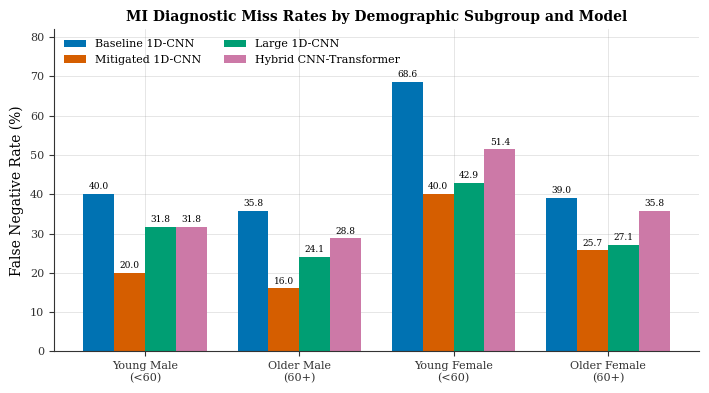

Figure 1 saved.


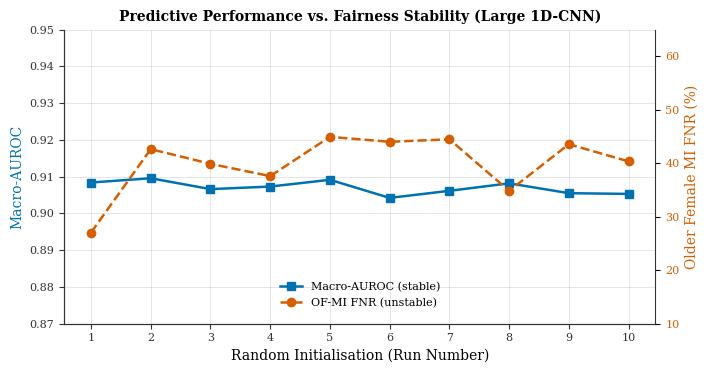

Figure 3 saved.


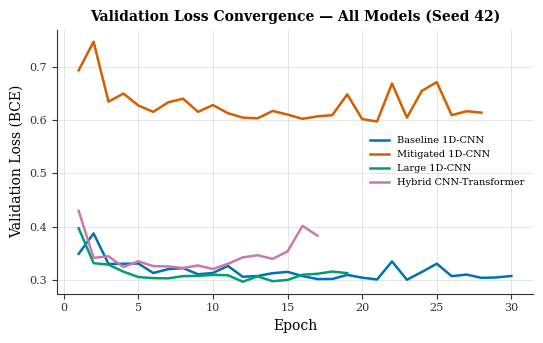

Figure 6 saved.


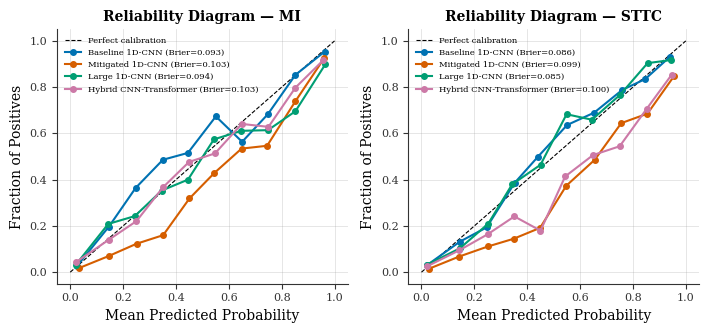

Figure 7 saved.


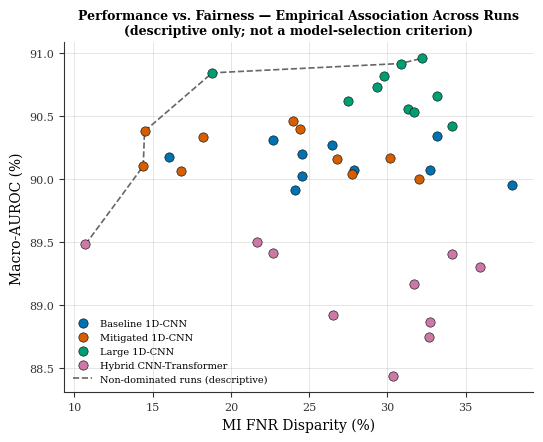

Figure 10 saved (descriptive association across runs, not a selection criterion).


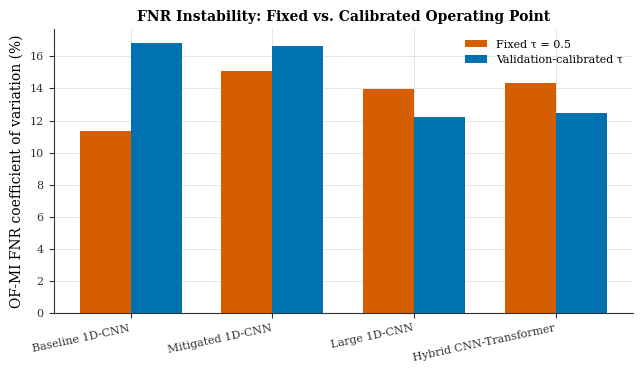

Figure 11 saved.

  Table 3: Multi-Run Classification Performance  (mean ± SD, 10 seeds)
  Model                         AUROC             F1                OF-MI FNR τ=0.5     OF-MI FNR calib.    CV-FNR(τ)
  --------------------------------------------------------------------------------------
  Baseline 1D-CNN               0.901±0.001  0.659±0.013  37.8±4.3  25.7±4.3  11.4%
  Mitigated 1D-CNN              0.902±0.002  0.684±0.004  20.3±3.1  25.6±4.3  15.1%
  Large 1D-CNN                  0.907±0.002  0.671±0.014  40.0±5.6  26.2±3.2  14.0%
  Hybrid CNN-Transformer        0.891±0.004  0.656±0.011  36.7±5.3  28.3±3.5  14.4%

All figures saved to /content/drive/MyDrive/ecg_fairness_project/figures/


In [ ]:
# %%
# ============================================================
# BLOCK 15: Paper Figures
# ============================================================

MODEL_COLORS = {
    'Baseline 1D-CNN':        '#0072B2',
    'Mitigated 1D-CNN':       '#D55E00',
    'Large 1D-CNN':           '#009E73',
    'Hybrid CNN-Transformer': '#CC79A7',
}

plt.rcParams.update({
    'font.family':         'serif',
    'font.serif':          ['Times New Roman', 'DejaVu Serif'],
    'font.size':            9,
    'axes.labelsize':       10,
    'axes.titlesize':       10,
    'axes.titleweight':    'bold',
    'legend.fontsize':      8,
    'xtick.labelsize':      8,
    'ytick.labelsize':      8,
    'axes.linewidth':       0.8,
    'axes.edgecolor':      '#333333',
    'axes.grid':            True,
    'grid.linewidth':       0.5,
    'grid.alpha':           0.35,
    'grid.color':          '#999999',
    'axes.axisbelow':       True,
    'savefig.dpi':          600,
    'savefig.bbox':        'tight',
    'pdf.fonttype':         42,
    'ps.fonttype':          42,
})


def _clean_axes(ax):
    """Remove top/right spines -- standard for IEEE/Nature-style figures."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#333333')
    ax.spines['bottom'].set_color('#333333')
    ax.tick_params(colors='#333333')


def _save_figure(fig, name: str):
    """Save both a vector PDF, for camera-ready typesetting with
    editable text, and a raster PNG for quick preview."""
    fig.savefig(SAVE_DIR + f'{name}.pdf')
    fig.savefig(SAVE_DIR + f'{name}.png', dpi=300)


SUBGROUP_LABELS = ['Young Male\n(<60)', 'Older Male\n(60+)',
                   'Young Female\n(<60)', 'Older Female\n(60+)']


def _mi_fnr_vec(model_name):
    fnr_d = results['single_run'][model_name]['fnr']['MI']
    return [(fnr_d.get(k, (0,))[0] or 0) * 100
            if isinstance(fnr_d.get(k), tuple)
            else (fnr_d.get(k) or 0) * 100
            for k in SUBGROUPS]


# ---- Figure 1: MI FNR grouped bar chart ----
models_bar = list(MODEL_COLORS.keys())
x      = np.arange(4)
width  = 0.2
offset = np.linspace(-(len(models_bar)-1)/2, (len(models_bar)-1)/2,
                      len(models_bar)) * width

fig1, ax1 = plt.subplots(figsize=(7.16, 4.0))
for mn, off in zip(models_bar, offset):
    vals  = _mi_fnr_vec(mn)
    rects = ax1.bar(x + off, vals, width, label=mn, color=MODEL_COLORS[mn])
    for r in rects:
        h = r.get_height()
        ax1.annotate(f'{h:.1f}', xy=(r.get_x() + r.get_width()/2, h),
                     xytext=(0, 2), textcoords='offset points',
                     ha='center', va='bottom', fontsize=6.5)

ax1.set_ylabel('False Negative Rate (%)')
ax1.set_title('MI Diagnostic Miss Rates by Demographic Subgroup and Model')
ax1.set_xticks(x)
ax1.set_xticklabels(SUBGROUP_LABELS)
ax1.legend(loc='upper left', frameon=False, ncol=2)
ax1.set_ylim(0, 82)
_clean_axes(ax1)
plt.tight_layout()
_save_figure(fig1, 'Figure1_MI_FNR')
plt.show()
print("Figure 1 saved.")

# ---- Figure 2 (removed): a polar/radar chart of older-female FNR
# by class was previously shown here. It plotted exactly the same
# Baseline-vs-Mitigated Older-Female FNR values already shown in
# Figure 1's grouped bar chart, in a harder-to-read format --
# removed as redundant rather than kept as a second view of
# identical numbers.

# ---- Figure 3: Stability — Large CNN ----
mr   = results['multi_run']['Large 1D-CNN']
runs = list(range(1, len(SEEDS) + 1))

fig3, ax_l = plt.subplots(figsize=(7.16, 3.8))
c_a, c_f = '#0072B2', '#D55E00'

ax_l.set_xlabel('Random Initialisation (Run Number)')
ax_l.set_ylabel('Macro-AUROC', color=c_a)
l1 = ax_l.plot(runs, mr['auroc'], color=c_a, marker='s', markersize=6,
               linewidth=1.8, label='Macro-AUROC (stable)')
ax_l.tick_params(axis='y', labelcolor=c_a)
ax_l.set_ylim(0.87, 0.95)
ax_l.set_xticks(runs)
_clean_axes(ax_l)

ax_r = ax_l.twinx()
ax_r.set_ylabel('Older Female MI FNR (%)', color=c_f)
l2 = ax_r.plot(runs, mr['fnr_fixed'], color=c_f, marker='o', markersize=6,
               linewidth=1.8, linestyle='--', label='OF-MI FNR (unstable)')
ax_r.tick_params(axis='y', labelcolor=c_f)
ax_r.set_ylim(10, 65)
ax_r.grid(False)
ax_r.spines['top'].set_visible(False)

all_lines = l1 + l2
ax_l.legend(all_lines, [l.get_label() for l in all_lines],
            loc='lower center', bbox_to_anchor=(0.5, 0.02), frameon=False)
ax_l.set_title('Predictive Performance vs. Fairness Stability (Large 1D-CNN)')
plt.tight_layout()
_save_figure(fig3, 'Figure3_Stability')
plt.show()
print("Figure 3 saved.")

# ---- Figure 5: Robustness -- three noise types ----
# Only generated if the optional noise-robustness diagnostic
# (Block 14) was actually run; skipped by default since
# RUN_OPTIONAL_DIAGNOSTICS defaults to False.
if RUN_OPTIONAL_DIAGNOSTICS and 'robustness_results' in globals():
    NOISE_STYLES = {
        'baseline_wander': ('#0072B2', '-',  'o', 'Baseline Wander'),
        'gaussian':        ('#D55E00', '--', 's', 'Gaussian Noise'),
        'powerline_50hz':  ('#009E73', ':',  '^', 'Powerline (50 Hz)'),
    }
    noise_levels_plot = [0.0, 0.1, 0.5, 1.0, 2.0]

    fig5, ax5 = plt.subplots(figsize=(5.5, 3.8))
    for nt, (color, ls, marker, label) in NOISE_STYLES.items():
        aurs = [robustness_results[nt][s] for s in noise_levels_plot]
        rauc = robustness_results[nt]['robustness_auc']
        ax5.plot(noise_levels_plot, aurs, color=color, linestyle=ls, marker=marker,
                 markersize=6, linewidth=1.8, label=f"{label} (R-AUC={rauc:.3f})")

    ax5.axhline(0.5, color='#999999', linestyle='--', linewidth=1.0)
    ax5.text(1.2, 0.515, 'Random Guessing', color='#666666', fontsize=7)
    ax5.set_xlabel('Noise Amplitude σ (normalised units)')
    ax5.set_ylabel('Macro-AUROC')
    ax5.set_title('Baseline 1D-CNN Robustness to Clinical Artifacts')
    ax5.set_xticks(noise_levels_plot)
    ax5.set_ylim(0.45, 0.95)
    ax5.legend(frameon=False, fontsize=6.5)
    _clean_axes(ax5)
    plt.tight_layout()
    _save_figure(fig5, 'Figure5_Robustness')
    plt.show()
    print("Figure 5 saved.")

# ---- Figure 6: Validation loss convergence ----
conv_data = {mname: hist for mname, hist in _histories.items() if hist is not None}

if not conv_data:
    print("No training history available for any model — skipping Figure 6. "
          "Delete the affected seed-42 checkpoints and rerun Block 11 to "
          "regenerate history, then rerun this cell.")
else:
    fig6, ax6 = plt.subplots(figsize=(5.5, 3.5))
    for mname, hist in conv_data.items():
        ep = list(range(1, hist['n_epochs'] + 1))
        ax6.plot(ep, hist['val_loss'], label=mname, color=MODEL_COLORS[mname], linewidth=1.8)
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Validation Loss (BCE)')
    ax6.set_title('Validation Loss Convergence — All Models (Seed 42)')
    ax6.legend(frameon=False, fontsize=7)
    _clean_axes(ax6)
    plt.tight_layout()
    _save_figure(fig6, 'Figure6_Convergence')
    plt.show()
    print("Figure 6 saved.")
    if len(conv_data) < len(MODEL_COLORS):
        missing = set(MODEL_COLORS) - set(conv_data)
        print(f"Note: missing history for {missing} — regenerate before finalizing.")

# ---- Figure 7: Reliability diagrams for MI and STTC ----
fig7, axes7 = plt.subplots(1, 2, figsize=(7.16, 3.4))

for ax, cls in zip(axes7, ['MI', 'STTC']):
    cls_idx = CLASSES.index(cls)
    ax.plot([0, 1], [0, 1], 'k--', linewidth=0.8, label='Perfect calibration')

    for mname, mdata in results['single_run'].items():
        tgt   = mdata['pred_dict']['targets'][:, cls_idx]
        probs = mdata['pred_dict']['probs'][:, cls_idx]
        if tgt.sum() < 20:
            continue
        prob_true, prob_pred = calibration_curve(tgt, probs, n_bins=10, strategy='uniform')
        brier = mdata['brier'][cls]
        ax.plot(prob_pred, prob_true, marker='o', markersize=4, linewidth=1.5,
                color=MODEL_COLORS.get(mname, 'grey'), label=f"{mname} (Brier={brier:.3f})")

    ax.set_xlabel('Mean Predicted Probability')
    ax.set_ylabel('Fraction of Positives')
    ax.set_title(f'Reliability Diagram — {cls}')
    ax.legend(loc='upper left', fontsize=6, frameon=False)
    _clean_axes(ax)

plt.tight_layout()
_save_figure(fig7, 'Figure7_Reliability')
plt.show()
print("Figure 7 saved.")

# ---- Figure 10: AUROC vs. MI FNR disparity, all individual runs ----
# Descriptive only: this plots the empirical association between
# aggregate performance and one fairness metric across all 40
# individual training runs. The "frontier" traces which runs were
# not dominated by another on both axes simultaneously -- it is
# not evidence of a causal trade-off, and should not be read as
# a model-selection criterion (a run's position here reflects one
# specific seed and threshold, not a property guaranteed to
# transfer to a freshly trained model of the same architecture).
def pareto_frontier(points: list) -> list:
    pts = sorted(points, key=lambda p: p[0])
    frontier, best_auroc = [], -1
    for disp, auroc in pts:
        if auroc > best_auroc:
            frontier.append((disp, auroc))
            best_auroc = auroc
    return frontier


fig10, ax10 = plt.subplots(figsize=(5.5, 4.5))
all_points = []
for mname in MODEL_COLORS:
    mr_ = results['multi_run'][mname]
    disp_vals  = mr_['fnr_disparity']['MI']
    auroc_vals = mr_['auroc']
    ax10.scatter(disp_vals, [a * 100 for a in auroc_vals][:len(disp_vals)],
                 color=MODEL_COLORS[mname], label=mname, s=45,
                 edgecolor='black', linewidth=0.4, zorder=3)
    all_points.extend(zip(disp_vals, [a * 100 for a in auroc_vals][:len(disp_vals)]))

frontier = pareto_frontier(all_points)
fx, fy = zip(*sorted(frontier))
ax10.plot(fx, fy, color='#666666', linestyle='--', linewidth=1.2, zorder=2,
          label='Non-dominated runs (descriptive)')

ax10.set_xlabel('MI FNR Disparity (%)')
ax10.set_ylabel('Macro-AUROC (%)')
ax10.set_title('Performance vs. Fairness — Empirical Association Across Runs\n'
                '(descriptive only; not a model-selection criterion)',
                fontsize=9)
ax10.legend(frameon=False, fontsize=7)
_clean_axes(ax10)
plt.tight_layout()
_save_figure(fig10, 'Figure10_Pareto_Frontier')
plt.show()
print("Figure 10 saved (descriptive association across runs, not a selection criterion).")

# ---- Figure 11: Fixed vs. calibrated-threshold FNR CV ----
fig11, ax11 = plt.subplots(figsize=(6.5, 3.8))
model_names = list(MODEL_COLORS.keys())
cv_fixed    = [results['multi_run'][m]['summary']['fnr_fixed'][3] for m in model_names]
cv_calib    = [results['multi_run'][m]['summary']['fnr_calibrated'][3] for m in model_names]

xb = np.arange(len(model_names))
ax11.bar(xb - 0.18, cv_fixed, 0.36, label='Fixed τ = 0.5',           color='#D55E00')
ax11.bar(xb + 0.18, cv_calib, 0.36, label='Validation-calibrated τ', color='#0072B2')
ax11.set_xticks(xb)
ax11.set_xticklabels(model_names, rotation=12, ha='right')
ax11.set_ylabel('OF-MI FNR coefficient of variation (%)')
ax11.set_title('FNR Instability: Fixed vs. Calibrated Operating Point')
ax11.legend(frameon=False)
_clean_axes(ax11)
plt.tight_layout()
_save_figure(fig11, 'Figure11_Threshold_Sensitivity')
plt.show()
print("Figure 11 saved.")

print_results_table()
print(f"All figures saved to {SAVE_DIR}")

In [ ]:
# %%
# ============================================================
# BLOCK 16: External Validation Dataset
#           Georgia 12-Lead ECG Challenge Database
#
# The Georgia database (Perez Alday et al., 2020; PhysioNet/CinC
# Challenge 2020) contains 10,344 twelve-lead recordings from the
# Southeastern United States, collected independently of PTB-XL.
# Recordings are provided in WFDB format at 500 Hz with age, sex,
# and SNOMED-CT diagnosis codes in each header file. Only the
# Georgia source is downloaded, not the full Challenge archive.
# ============================================================

EXTERNAL_DIR = '/content/georgia'

if os.path.exists(EXTERNAL_DIR) and len(os.listdir(EXTERNAL_DIR)) > 0:
    print(f"Georgia database already present at: {EXTERNAL_DIR}")
else:
    print("Downloading the Georgia 12-lead ECG database from PhysioNet...")
    subprocess.run(
        ["wget", "-r", "-N", "-c", "-np", "-nH", "--cut-dirs=4",
         "-R", "index.html*", "-P", "/content",
         "https://physionet.org/files/challenge-2020/1.0.2/training/georgia/"],
        check=True
    )
    assert os.path.exists(EXTERNAL_DIR), f"Download failed. Expected: {EXTERNAL_DIR}"
    print(f"Georgia database ready: {EXTERNAL_DIR}")

_georgia_headers = sorted(glob.glob(f"{EXTERNAL_DIR}/**/*.hea", recursive=True))
print(f"Georgia recordings found: {len(_georgia_headers):,}")

Georgia database ready: /content/georgia
Georgia recordings found: 10,344


In [ ]:
# %%
# ============================================================
# BLOCK 17: SNOMED-CT to Diagnostic Superclass Mapping
#
#   NORM  — normal sinus rhythm and its benign variants
#   MI    — myocardial infarction, any territory or stage
#   STTC  — ischaemic ST/T-wave change without infarction
#   CD    — atrioventricular, bundle-branch, or fascicular block
#   HYP   — atrial or ventricular hypertrophy
#
# Diagnoses outside these five categories fall outside PTB-XL's own
# diagnostic taxonomy and are not scored. Recordings whose only
# diagnoses fall in that remainder are excluded in Block 18. The
# full crosswalk is printed below for manual review.
#
# A second, more conservative mapping is also built here (see
# _SUPERCLASS_KEYWORDS_CONSERVATIVE below) retaining only the
# clearly unambiguous diagnoses, as a sensitivity check on how
# much the external cohort depends on the main mapping's
# permissiveness. Block 18 applies both and reports the resulting
# difference in cohort composition. Neither mapping has been
# reviewed by a clinician; that remains a real, disclosed
# limitation of the external validation (see Limitations).
# ============================================================

DX_MAP_URL = ("https://raw.githubusercontent.com/physionetchallenges/"
              "physionetchallenges.github.io/master/2020/Dx_map.csv")
dx_map_df  = pd.read_csv(DX_MAP_URL)
dx_map_df.columns = ['description', 'snomed_code', 'abbreviation']

_SUPERCLASS_KEYWORDS = {
    'NORM': ['sinus rhythm', 'sinus arrhythmia'],
    'MI':   ['myocardial infarction'],
    'STTC': ['ischemia', 'ischaemia', 'st segment', 't wave abnormal',
             'st-t', 'nonspecific st'],
    'CD':   ['av block', 'atrioventricular block', 'bundle branch block',
             'fascicular block', 'intraventricular conduction',
             'wolff-parkinson-white'],
    'HYP':  ['hypertrophy'],
}

# A narrower, more conservative keyword set retaining only the
# clearly, unambiguously compatible diagnoses -- excluding terms
# that are either explicitly nonspecific in clinical usage
# ('nonspecific st', generic 'st segment'/'t wave abnormal'
# findings) or arguably a distinct clinical entity rather than a
# conduction block proper (Wolff-Parkinson-White is a
# pre-excitation syndrome, not a block; 'intraventricular
# conduction' delay is vaguer than a named block). This is a
# reasoned, disclosed judgement call, not a clinically validated
# review -- used below only as a sensitivity check on how much the
# external cohort's composition depends on the mapping's
# permissiveness, not as a replacement for the main crosswalk.
_SUPERCLASS_KEYWORDS_CONSERVATIVE = {
    'NORM': ['sinus rhythm', 'sinus arrhythmia'],
    'MI':   ['myocardial infarction'],
    'STTC': ['ischemia', 'ischaemia'],
    'CD':   ['av block', 'atrioventricular block', 'bundle branch block',
             'fascicular block'],
    'HYP':  ['hypertrophy'],
}


def map_description_to_superclass(description, keywords=_SUPERCLASS_KEYWORDS):
    """Assign a SNOMED-CT description to a superclass, or None if
    outside the taxonomy. MI is checked before STTC so infarction-
    specific phrasing is never re-classified as ischaemia."""
    text = description.lower()
    for superclass, kws in keywords.items():
        if any(kw in text for kw in kws):
            return superclass
    return None

dx_map_df['superclass'] = dx_map_df['description'].apply(map_description_to_superclass)
dx_map_df['superclass_conservative'] = dx_map_df['description'].apply(
    lambda d: map_description_to_superclass(d, _SUPERCLASS_KEYWORDS_CONSERVATIVE))

dx_map_df['snomed_code'] = (
    dx_map_df['snomed_code']
    .astype(str)
    .str.replace(r'\.0$', '', regex=True)
    .str.strip()
)

SNOMED_TO_SUPERCLASS = dict(zip(dx_map_df['snomed_code'], dx_map_df['superclass']))
SNOMED_TO_SUPERCLASS_CONSERVATIVE = dict(zip(dx_map_df['snomed_code'],
                                              dx_map_df['superclass_conservative']))

print("SNOMED-CT -> Diagnostic Superclass crosswalk:")
print(dx_map_df[dx_map_df['superclass'].notna()]
      [['description', 'snomed_code', 'superclass']]
      .sort_values('superclass').to_string(index=False))
print(f"\n{dx_map_df['superclass'].notna().sum()} of {len(dx_map_df)} SNOMED-CT "
      f"codes map onto the five-superclass taxonomy.")

_n_dropped_by_conservative = (
    dx_map_df['superclass'].notna() & dx_map_df['superclass_conservative'].isna()
).sum()
print(f"\nConservative mapping (sensitivity check): "
      f"{dx_map_df['superclass_conservative'].notna().sum()} of {len(dx_map_df)} "
      f"codes retained; {_n_dropped_by_conservative} code(s) that mapped under "
      f"the main crosswalk are excluded as too nonspecific or ambiguous under "
      f"the conservative one. See Block 18 for the resulting cohort-composition "
      f"comparison.")

SNOMED-CT -> Diagnostic Superclass crosswalk:
                                     description snomed_code superclass
                             1st degree av block   270492004         CD
                       right bundle branch block    59118001         CD
nonspecific intraventricular conduction disorder   698252002         CD
 mobitz type i wenckebach atrioventricular block    54016002         CD
                 left posterior fascicular block   445211001         CD
                        left bundle branch block   164909002         CD
            incomplete right bundle branch block   713426002         CD
             incomplete left bundle branch block   251120003         CD
              complete right bundle branch block   713427006         CD
                  left anterior fascicular block   445118002         CD
                             bundle branch block     6374002         CD
                                        av block   233917008         CD
                  

In [ ]:
# %%
# ============================================================
# BLOCK 18: External Preprocessing, Dataset & DataLoader
#
# Signals are resampled from their native 500 Hz to 100 Hz and
# truncated or zero-padded to 1000 samples, then per-lead z-score
# normalised identically to PTBXLDataset — no architectural or
# preprocessing changes are made across the domain shift.
# ============================================================

PTBXL_FS, PTBXL_LEN = 100, 1000


def parse_georgia_header(path: str) -> dict:
    """Extract age, sex, and Dx SNOMED codes from a WFDB header.
    Tolerant of an optional space after '#' and of field-name case,
    since these vary across PhysioNet Challenge sources."""
    age, sex, dx_codes = np.nan, np.nan, []
    with open(path) as f:
        for line in f:
            line = line.strip()
            if not line.startswith('#'):
                continue
            content = line.lstrip('#').strip()
            field, _, value = content.partition(':')
            field = field.strip().lower()
            value = value.strip()

            if field == 'age':
                age = float(value) if value.replace('.', '', 1).isdigit() else np.nan
            elif field == 'sex':
                value_l = value.lower()
                if value_l.startswith('f'):
                    sex = 1
                elif value_l.startswith('m'):
                    sex = 0
            elif field == 'dx':
                dx_codes = [c.strip() for c in value.split(',') if c.strip()]

    return {'age': age, 'sex': sex, 'dx_codes': dx_codes}


def build_georgia_dataframe(header_paths: list,
                             snomed_map: dict = None) -> pd.DataFrame:
    """Parse all headers and multi-hot encode the five superclasses.
    `snomed_map` defaults to the main crosswalk (SNOMED_TO_SUPERCLASS);
    pass SNOMED_TO_SUPERCLASS_CONSERVATIVE to build the comparison
    cohort used in the mapping-sensitivity check below."""
    if snomed_map is None:
        snomed_map = SNOMED_TO_SUPERCLASS
    records = []
    for path in header_paths:
        meta   = parse_georgia_header(path)
        labels = {c: 0 for c in CLASSES}
        for code in meta['dx_codes']:
            superclass = snomed_map.get(code)
            if superclass is not None:
                labels[superclass] = 1
        if sum(labels.values()) == 0:
            continue
        records.append({
            'record_path': path[:-len('.hea')],
            'age': meta['age'],
            'sex': meta['sex'],
            **{f'label_{c}': labels[c] for c in CLASSES},
        })
    return pd.DataFrame(records)

georgia_df = build_georgia_dataframe(_georgia_headers)

if len(georgia_df) == 0:
    sample_codes = []
    for path in _georgia_headers[:20]:
        sample_codes.extend(parse_georgia_header(path)['dx_codes'])
    print("No Georgia records matched the five-superclass taxonomy.")
    print(f"Sample codes seen in headers: {sorted(set(sample_codes))[:15]}")
    print(f"Sample codes in crosswalk:    {sorted(SNOMED_TO_SUPERCLASS.keys())[:15]}")
    raise RuntimeError(
        "georgia_df is empty — compare the two code lists printed above; "
        "a formatting mismatch (e.g. trailing '.0') means the join is failing silently."
    )

georgia_df = georgia_df.dropna(subset=['sex']).reset_index(drop=True)
georgia_df['age'] = georgia_df['age'].fillna(georgia_df['age'].median())

def _has_finite_signal(record_path: str) -> bool:
    """
    True if a record's raw signal contains no NaN/Inf samples. A
    minority of Georgia recordings encode missing samples using a
    WFDB sentinel value that wfdb.rdsamp converts to NaN; scipy's
    FFT-based resample then spreads that single NaN across every
    sample in the resampled channel, corrupting model input.
    """
    try:
        signal, _ = wfdb.rdsamp(record_path)
    except Exception:
        return False
    return np.isfinite(signal).all()


_n_before   = len(georgia_df)
finite_mask = georgia_df['record_path'].apply(_has_finite_signal)
georgia_df  = georgia_df[finite_mask].reset_index(drop=True)
print(f"Excluded {_n_before - len(georgia_df)} of {_n_before} recordings "
      f"with non-finite (NaN/Inf) raw signal values.")

print(f"Georgia external test set: {len(georgia_df):,} recordings")
print("\nClass prevalence:")
for c in CLASSES:
    print(f"  {c}: {int(georgia_df[f'label_{c}'].sum()):,}")
print(f"\nFemale: {(georgia_df['sex'] == 1).mean():.1%}  |  "
      f"Age >= 60: {(georgia_df['age'] >= 60).mean():.1%}")


class GeorgiaECGDataset(Dataset):
    """Streaming loader for the Georgia database, resampled to the
    100 Hz / 1000-sample format the PTB-XL-trained models expect."""
    def __init__(self, df: pd.DataFrame, class_names: list):
        self.df     = df
        self.labels = df[[f'label_{c}' for c in class_names]].values.astype(np.float32)
        self.sex    = df['sex'].values.astype(np.float32)
        self.age    = df['age'].values.astype(np.float32)

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        signal, meta = wfdb.rdsamp(self.df.iloc[idx]['record_path'])
        signal = np.nan_to_num(signal, nan=0.0, posinf=0.0, neginf=0.0)
        native_fs = meta['fs']
        n_target     = int(round(signal.shape[0] * PTBXL_FS / native_fs))
        signal       = sp_resample(signal, n_target, axis=0)

        if len(signal) >= PTBXL_LEN:
            signal = signal[:PTBXL_LEN]
        else:
            signal = np.pad(signal, ((0, PTBXL_LEN - len(signal)), (0, 0)))

        signal = signal.T
        mu     = signal.mean(axis=1, keepdims=True)
        sigma  = signal.std(axis=1, keepdims=True)
        signal = (signal - mu) / (sigma + 1e-8)

        return (
            torch.tensor(signal, dtype=torch.float32),
            torch.tensor(self.labels[idx], dtype=torch.float32),
            {'sex': self.sex[idx], 'age': self.age[idx], 'ecg_id': idx},
        )


georgia_dataset = GeorgiaECGDataset(georgia_df, CLASSES)
georgia_loader  = DataLoader(georgia_dataset, batch_size=BATCH_SIZE,
                             shuffle=False, num_workers=0, pin_memory=False)

for x, y, _ in georgia_loader:
    print(f"\nGeorgia batch shape — Signal: {x.shape}  Labels: {y.shape}")
    break

# ------------------------------------------------------------
# Conservative-mapping sensitivity check (Block 17 built a second,
# narrower crosswalk: SNOMED_TO_SUPERCLASS_CONSERVATIVE). This
# builds a second Georgia cohort under that mapping and reports how
# cohort composition changes -- entirely separate from georgia_df,
# georgia_dataset, and georgia_loader above, which remain built on
# the main (inclusive) mapping used throughout the rest of this
# notebook. This exploratory mapping comparison is not clinical validation
# and must not be optimized using model performance.
# ------------------------------------------------------------

georgia_df_conservative = build_georgia_dataframe(
    _georgia_headers, snomed_map=SNOMED_TO_SUPERCLASS_CONSERVATIVE)
georgia_df_conservative = georgia_df_conservative.dropna(subset=['sex']).reset_index(drop=True)
# The conservative map is a subset of the main map. Reuse the main
# cohort's finite-signal eligibility and imputed ages without rereading signals.
valid_paths = set(georgia_df['record_path'])
georgia_df_conservative = georgia_df_conservative[
    georgia_df_conservative['record_path'].isin(valid_paths)].copy().reset_index(drop=True)
main_ages = georgia_df.set_index('record_path')['age']
georgia_df_conservative['age'] = georgia_df_conservative['record_path'].map(main_ages)

print(f"\n{'='*72}")
print("  Crosswalk Sensitivity Check: Main vs. Conservative Mapping")
print(f"{'='*72}")
print(f"  {'':<14}{'Main (inclusive)':<20}{'Conservative':<20}")
print(f"  {'N recordings':<14}{len(georgia_df):<20,}{len(georgia_df_conservative):<20,}")
for c in CLASSES:
    n_main = int(georgia_df[f'label_{c}'].sum())
    n_cons = int(georgia_df_conservative[f'label_{c}'].sum()) if len(georgia_df_conservative) else 0
    print(f"  {c:<14}{n_main:<20,}{n_cons:<20,}")
if len(georgia_df_conservative):
    print(f"  {'Female %':<14}{(georgia_df['sex']==1).mean():<20.1%}"
          f"{(georgia_df_conservative['sex']==1).mean():<20.1%}")
    print(f"  {'Age>=60 %':<14}{(georgia_df['age']>=60).mean():<20.1%}"
          f"{(georgia_df_conservative['age']>=60).mean():<20.1%}")
print(f"\n  Note: this is a code-only sensitivity check, not a clinician-")
print(f"  reviewed crosswalk. It shows how much cohort composition")
print(f"  depends on the mapping's permissiveness, not which mapping")
print(f"  is clinically correct.")


Excluded 2 of 8146 recordings with non-finite (NaN/Inf) raw signal values.
Georgia external test set: 8,144 recordings

Class prevalence:
  NORM: 2,205
  MI: 7
  STTC: 4,171
  CD: 2,230
  HYP: 1,368

Female: 46.8%  |  Age >= 60: 57.8%

Georgia batch shape — Signal: torch.Size([32, 12, 1000])  Labels: torch.Size([32, 5])

  Crosswalk Sensitivity Check: Main vs. Conservative Mapping
                Main (inclusive)    Conservative        
  N recordings  8,144               6,259               
  NORM          2,205               2,205               
  MI            7                   7                   
  STTC          4,171               1,588               
  CD            2,230               2,051               
  HYP           1,368               1,368               
  Female %      46.8%               45.9%               
  Age>=60 %     57.8%               57.1%               

  Note: this is a code-only sensitivity check, not a clinician-
  reviewed crosswalk. It shows how muc

In [ ]:
# %%
# ============================================================
# BLOCK 19: Zero-Shot External Inference — Overall Performance
#
# Every model already trained on PTB-XL is evaluated on Georgia
# with no retraining, no fine-tuning, and no access to Georgia
# demographic labels during inference.
# ============================================================

results['external'] = {'single_run': {}, 'multi_run': {}}

_external_specs = [
    ('Baseline 1D-CNN',        ECG_1D_CNN),
    ('Mitigated 1D-CNN',       ECG_1D_CNN),
    ('Large 1D-CNN',           ECG_Large_CNN),
    ('Hybrid CNN-Transformer', Hybrid_ECG_Transformer),
]

print(f"{'Model':<32}  {'AUROC [95% CI]':<26}  {'F1 [95% CI]':<26}  Brier")
print("-" * 92)

for mname, mclass in _external_specs:
    model    = load_checkpoint(mclass(num_classes=5), mname, PRIMARY_SEED)
    pd_      = get_predictions(model, georgia_loader)
    metrics  = compute_overall_metrics(pd_)
    brier    = compute_brier_scores(pd_)
    auroc_ci = bootstrap_metric_ci(pd_, metric='auroc')
    f1_ci    = bootstrap_metric_ci(pd_, metric='f1')

    results['external']['single_run'][mname] = {
        'auroc': metrics['auroc'], 'f1': metrics['f1'],
        'auroc_ci': auroc_ci, 'f1_ci': f1_ci, 'brier': brier, 'pred_dict': pd_,
    }
    print(f"{mname:<32}  "
          f"{metrics['auroc']:.4f} [{auroc_ci[0]:.4f},{auroc_ci[1]:.4f}]  "
          f"{metrics['f1']:.4f} [{f1_ci[0]:.4f},{f1_ci[1]:.4f}]  "
          f"{brier['macro']:.4f}")

Model                             AUROC [95% CI]              F1 [95% CI]                 Brier
--------------------------------------------------------------------------------------------
auroc record-bootstrap CI: 999/1000 valid resamples.
f1 record-bootstrap CI: 1000/1000 valid resamples.
Baseline 1D-CNN                   0.7990 [0.7622,0.8272]  0.4385 [0.4315,0.4460]  0.1579
auroc record-bootstrap CI: 999/1000 valid resamples.
f1 record-bootstrap CI: 1000/1000 valid resamples.
Mitigated 1D-CNN                  0.7950 [0.7631,0.8223]  0.4947 [0.4890,0.5005]  0.1955
auroc record-bootstrap CI: 999/1000 valid resamples.
f1 record-bootstrap CI: 1000/1000 valid resamples.
Large 1D-CNN                      0.8008 [0.7656,0.8312]  0.4464 [0.4393,0.4541]  0.1654
auroc record-bootstrap CI: 999/1000 valid resamples.
f1 record-bootstrap CI: 1000/1000 valid resamples.
Hybrid CNN-Transformer            0.7718 [0.7281,0.8155]  0.4589 [0.4520,0.4667]  0.1670


In [ ]:
# %%
# ============================================================
# BLOCK 20: External Fairness Audit
#
# The same FNR-parity, equalized-odds, and subgroup-count
# machinery used for PTB-XL is applied unmodified to the Georgia
# predictions.
# ============================================================

for mname, mdata in results['external']['single_run'].items():
    fnr       = compute_fnr_by_group(mdata['pred_dict'], with_ci=True)
    fpr       = compute_fpr_by_group(mdata['pred_dict'], with_ci=True)
    disparity = compute_fnr_disparity(fnr)
    eo_gap    = compute_equalized_odds_gap(fnr, fpr)
    counts    = compute_subgroup_counts(mdata['pred_dict'])

    mdata['fnr']       = fnr
    mdata['fpr']       = fpr
    mdata['disparity'] = disparity
    mdata['eo_gap']    = eo_gap
    mdata['counts']    = counts

    print_fairness_report(f"{mname} — Georgia (External)", fnr, disparity, counts)
    print_equalized_odds_report(f"{mname} — Georgia (External)", fnr, fpr)


  Baseline 1D-CNN — Georgia (External)  —  Intersectional Fairness Audit (Test Set, Fold 10)
  FNR = FN / (FN + TP)  |  95% CI via 1000-sample bootstrap

  NORM  [disparity = 15.4%]:
    Young Male (<60)         | FNR = 25.7%  [95% CI: 22.4%, 29.0%]  (n=584 positive)
    Older Male (60+)         | FNR = 39.3%  [95% CI: 34.9%, 43.8%]  (n=438 positive)
    Young Female (<60)       | FNR = 23.8%  [95% CI: 20.6%, 26.9%]  (n=684 positive)
    Older Female (60+)       | FNR = 37.7%  [95% CI: 33.4%, 41.8%]  (n=499 positive)

  MI  [disparity = 66.7%]:
    Young Male (<60)         | FNR = 0.0%  [95% CI: nan%, nan%]  (n=1 positive)
    Older Male (60+)         | FNR = 66.7%  [95% CI: nan%, nan%]  (n=3 positive)
    Young Female (<60)       | N/A  (n=0 positive)
    Older Female (60+)       | FNR = 33.3%  [95% CI: nan%, nan%]  (n=3 positive)

  STTC  [disparity = 7.6%]:
    Young Male (<60)         | FNR = 46.5%  [95% CI: 43.1%, 49.8%]  (n=846 positive)
    Older Male (60+)         | FNR = 45.5

In [ ]:
# %%
# ============================================================
# BLOCK 21: Cross-Domain Stability Analysis
#
# Block 12 already trained each architecture across ten
# independent seeds. Reusing those checkpoints here, with no
# additional training, tests whether the AUROC-stable / FNR-
# unstable discordance replicates under domain shift.
#
# STTC is tracked as the headline cross-domain fairness metric
# rather than MI: Georgia's MI prevalence under SNOMED-CT mapping
# (n=7 total, n=0-3 per subgroup) is too sparse to distinguish
# genuine instability from single-case sampling noise. STTC
# (n=1195 in the Older Female subgroup) supports a meaningful
# estimate. MI is still tracked and reported separately, flagged
# as underpowered.
# ============================================================

def run_external_stability(model_class, model_name: str,
                            seeds: list = SEEDS,
                            tracked_class: str = 'STTC',
                            tracked_group: str = 'Older Female (60+)') -> dict:
    """Load each existing seed checkpoint and evaluate on Georgia."""
    run_auroc, run_fnr_tracked, run_fnr_mi = [], [], []
    run_disparity = {cls: [] for cls in CLASSES}

    for seed in seeds:
        model    = load_checkpoint(model_class(num_classes=5), model_name, seed)
        pd_      = get_predictions_cached(model, georgia_loader, model_name, seed, split='external')
        met      = compute_overall_metrics(pd_)
        fnr_dict = compute_fnr_by_group(pd_)
        disp     = compute_fnr_disparity(fnr_dict)

        tracked_val = fnr_dict[tracked_class].get(tracked_group)
        mi_val      = fnr_dict['MI'].get(tracked_group)

        run_auroc.append(met['auroc'])
        if tracked_val is not None:
            run_fnr_tracked.append(tracked_val * 100)
        if mi_val is not None:
            run_fnr_mi.append(mi_val * 100)
        for cls in CLASSES:
            if disp.get(cls) is not None:
                run_disparity[cls].append(disp[cls] * 100)

    am, as_, aci = calc_stats(run_auroc)
    tm, ts_, tci = calc_stats(run_fnr_tracked)
    auroc_cv     = as_ / am * 100
    tracked_cv   = ts_ / tm * 100 if tm > 0 else 0

    print(f"\n{model_name}  (Georgia, {len(seeds)} seeds)")
    print(f"  AUROC                        : {am:.4f} ± {as_:.4f}  CV = {auroc_cv:.2f}%")
    print(f"  OF-{tracked_class} FNR (well-powered) : {tm:.2f}% ± {ts_:.2f}%  CV = {tracked_cv:.2f}%")
    if run_fnr_mi:
        mm, ms_, _ = calc_stats(run_fnr_mi)
        mi_cv = ms_ / mm * 100 if mm > 0 else float('nan')
        print(f"  OF-MI FNR (n=3, underpowered) : {mm:.2f}% ± {ms_:.2f}%  "
              f"CV = {mi_cv:.2f}%  [not used for cross-domain comparison]")

    return {
        'auroc': run_auroc,
        'fnr_tracked': run_fnr_tracked, 'tracked_class': tracked_class,
        'fnr_mi_underpowered': run_fnr_mi,
        'fnr_disparity': run_disparity,
        'summary': {
            'auroc':   (am, as_, aci, auroc_cv),
            'tracked': (tm, ts_, tci, tracked_cv),
        },
    }


for mname, mclass in _external_specs:
    results['external']['multi_run'][mname] = run_external_stability(mclass, mname)

print(f"\n{'='*95}")
print(f"  Table: Cross-Domain Stability — PTB-XL (Internal, MI) vs. Georgia (External, STTC)")
print(f"{'='*95}")
print(f"  {'Model':<28}  {'PTB-XL AUROC CV':<16}  {'Georgia AUROC CV':<17}  "
      f"{'PTB-XL MI-FNR CV':<17}  {'Georgia STTC-FNR CV'}")
print(f"  {'-'*95}")
for mname, mclass in _external_specs:
    ptbxl_cv    = results['multi_run'][mname]['summary']['auroc'][3]
    georgia_cv  = results['external']['multi_run'][mname]['summary']['auroc'][3]
    ptbxl_fcv   = results['multi_run'][mname]['summary']['fnr_fixed'][3]
    georgia_fcv = results['external']['multi_run'][mname]['summary']['tracked'][3]
    print(f"  {mname:<28}  {ptbxl_cv:>13.2f}%  {georgia_cv:>14.2f}%  "
          f"{ptbxl_fcv:>14.1f}%  {georgia_fcv:>17.1f}%")

# ------------------------------------------------------------
# Genuinely matched comparison: internal PTB-XL Older-Female
# STTC FNR CV vs. external Georgia Older-Female STTC FNR CV --
# same class on both sides, unlike the MI-vs-STTC comparison
# above. Uses the already-cached test-set predictions from
# Block 12; no new inference against PTB-XL.
# ------------------------------------------------------------

STTC_INDEX = CLASSES.index('STTC')

print(f"\n{'='*95}")
print(f"  Matched Same-Class Comparison: Internal vs. External Older-Female STTC FNR")
print(f"{'='*95}")
print(f"  {'Model':<28}{'Internal (PTB-XL) STTC FNR CV':<32}{'External (Georgia) STTC FNR CV'}")
print(f"  {'-'*95}")

internal_sttc_cv = {}
for mname, mclass in _external_specs:
    of_sttc_fnrs = []
    for seed in SEEDS:
        model = load_checkpoint(mclass(num_classes=5), mname, seed)
        pd_ = get_predictions_cached(model, test_loader, mname, seed, split='test')
        sex, age = pd_['sex'], pd_['age']
        of_mask = SUBGROUPS['Older Female (60+)'](sex, age)
        y_true = pd_['targets'][:, STTC_INDEX][of_mask]
        y_pred = pd_['preds'][:, STTC_INDEX][of_mask]
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        if (fn + tp) > 0:
            of_sttc_fnrs.append(fn / (fn + tp) * 100)

    arr = np.array(of_sttc_fnrs)
    cv = arr.std(ddof=1) / arr.mean() * 100
    internal_sttc_cv[mname] = cv
    georgia_sttc_cv = results['external']['multi_run'][mname]['summary']['tracked'][3]
    print(f"  {mname:<28}{cv:<32.2f}{georgia_sttc_cv:.2f}")

print(f"\n  Note: this compares the SAME class (STTC) internally and externally,")
print(f"  unlike the PTB-XL-MI-vs-Georgia-STTC comparison in the table above,")
print(f"  which necessarily compares across different classes because Georgia's")
print(f"  MI prevalence is too sparse for subgroup-level estimation.")



Baseline 1D-CNN  (Georgia, 10 seeds)
  AUROC                        : 0.7959 ± 0.0053  CV = 0.67%
  OF-STTC FNR (well-powered) : 37.55% ± 2.20%  CV = 5.86%
  OF-MI FNR (n=3, underpowered) : 23.33% ± 16.10%  CV = 69.01%  [not used for cross-domain comparison]

Mitigated 1D-CNN  (Georgia, 10 seeds)
  AUROC                        : 0.7974 ± 0.0063  CV = 0.79%
  OF-STTC FNR (well-powered) : 23.12% ± 1.70%  CV = 7.34%
  OF-MI FNR (n=3, underpowered) : 10.00% ± 16.10%  CV = 161.02%  [not used for cross-domain comparison]

Large 1D-CNN  (Georgia, 10 seeds)
  AUROC                        : 0.8056 ± 0.0050  CV = 0.62%
  OF-STTC FNR (well-powered) : 33.62% ± 2.90%  CV = 8.61%
  OF-MI FNR (n=3, underpowered) : 26.67% ± 26.29%  CV = 98.60%  [not used for cross-domain comparison]

Hybrid CNN-Transformer  (Georgia, 10 seeds)
  AUROC                        : 0.7809 ± 0.0066  CV = 0.85%
  OF-STTC FNR (well-powered) : 35.26% ± 4.08%  CV = 11.56%
  OF-MI FNR (n=3, underpowered) : 13.33% ± 17.21%  CV = 

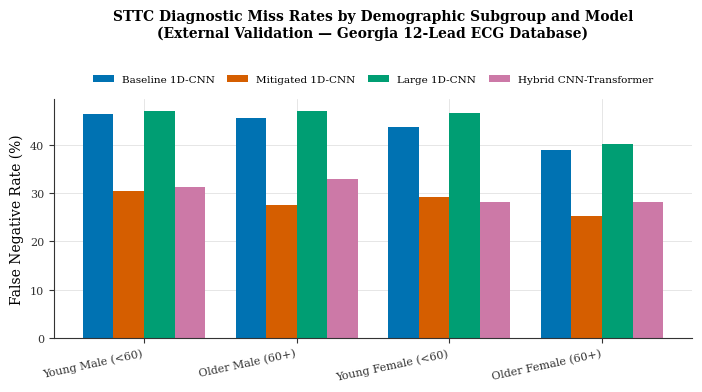

Figure 8 saved.

Subgroup positive counts for STTC (Georgia), for reference:
  Young Male (<60): n=846
  Older Male (60+): n=1357
  Young Female (<60): n=773
  Older Female (60+): n=1195


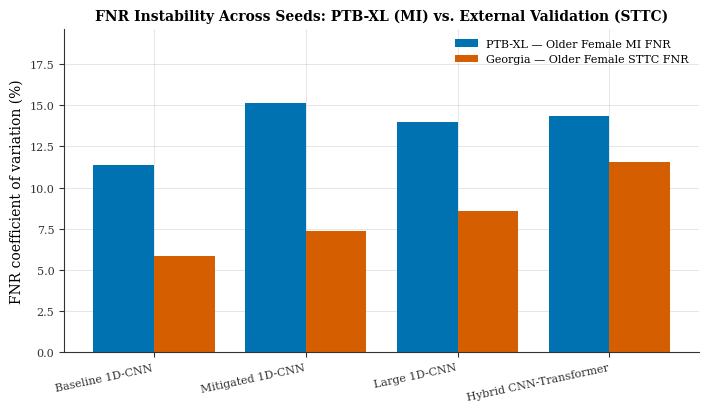

Figure 9 saved.

Note: Georgia MI prevalence (n=7 total) was too sparse for reliable subgroup-level FNR reporting; STTC is reported here as the best-powered comparable class. Georgia's own MI results are available in results['external']['multi_run'][model]['fnr_mi_underpowered'] and reported separately with an explicit low-power caveat.


In [ ]:
# %%
# ============================================================
# BLOCK 22: External Validation Figures
#
# STTC is used as the headline subgroup fairness metric for
# Georgia rather than MI: Georgia's MI prevalence under SNOMED-CT
# mapping (n=7 total) is too sparse to support a meaningful
# subgroup-level FNR estimate, whereas STTC (n=4,171) gives well-
# powered comparisons across all four intersectional subgroups.
# ============================================================

EXTERNAL_TRACKED_CLASS = 'STTC'

fig8, ax8   = plt.subplots(figsize=(7.16, 4.0))
group_names = list(SUBGROUPS.keys())
x           = np.arange(len(group_names))
width       = 0.2

for i, (mname, _) in enumerate(_external_specs):
    fnr_dict = results['external']['single_run'][mname]['fnr']
    counts   = results['external']['single_run'][mname]['counts']
    vals, ns = [], []
    for g in group_names:
        v = fnr_dict[EXTERNAL_TRACKED_CLASS][g]
        v = v[0] if isinstance(v, tuple) else v
        vals.append((v or 0) * 100)
        ns.append(counts[EXTERNAL_TRACKED_CLASS][g])
    rects = ax8.bar(x + (i - 1.5) * width, vals, width,
                    label=mname, color=MODEL_COLORS[mname])

ax8.set_xticks(x)
ax8.set_xticklabels(group_names, rotation=12, ha='right')
ax8.set_ylabel('False Negative Rate (%)')
ax8.set_title(f'{EXTERNAL_TRACKED_CLASS} Diagnostic Miss Rates by Demographic Subgroup and Model\n'
              '(External Validation — Georgia 12-Lead ECG Database)', pad=45)
ax8.legend(loc='upper center', bbox_to_anchor=(0.5, 1.14), ncol=4,
           frameon=False, fontsize=7.5, columnspacing=1.2)
_clean_axes(ax8)
plt.tight_layout()
_save_figure(fig8, 'Figure8_External_STTC_FNR')
plt.show()
print("Figure 8 saved.")

print(f"\nSubgroup positive counts for {EXTERNAL_TRACKED_CLASS} (Georgia), for reference:")
ref_counts = results['external']['single_run']['Baseline 1D-CNN']['counts'][EXTERNAL_TRACKED_CLASS]
for g, n in ref_counts.items():
    print(f"  {g}: n={n}")

# ---- Figure 9: Cross-domain FNR-CV comparison ----
# PTB-XL's bars report Older Female MI FNR CV (its own well-powered
# headline class); Georgia's bars report Older Female STTC FNR CV,
# the best-powered comparable class in this external cohort. The
# two are not the same disease category -- the legend states this
# explicitly rather than implying a like-for-like MI comparison.
fig9, ax9   = plt.subplots(figsize=(7.16, 4.2))
model_names = [m for m, _ in _external_specs]
ptbxl_cvs   = [results['multi_run'][m]['summary']['fnr_fixed'][3] for m in model_names]
georgia_cvs = [results['external']['multi_run'][m]['summary']['tracked'][3] for m in model_names]

xg = np.arange(len(model_names))
ax9.bar(xg - 0.2, ptbxl_cvs,   0.4, label='PTB-XL — Older Female MI FNR',
        color='#0072B2')
ax9.bar(xg + 0.2, georgia_cvs, 0.4, label=f'Georgia — Older Female {EXTERNAL_TRACKED_CLASS} FNR',
        color='#D55E00')
ax9.set_xticks(xg)
ax9.set_xticklabels(model_names, rotation=12, ha='right')
ax9.set_ylabel('FNR coefficient of variation (%)')
ax9.set_title('FNR Instability Across Seeds: PTB-XL (MI) vs. External Validation (STTC)')
ax9.set_ylim(0, max(ptbxl_cvs + georgia_cvs) * 1.3)   # headroom so the legend clears the bars
ax9.legend(frameon=False)
_clean_axes(ax9)
plt.tight_layout()
_save_figure(fig9, 'Figure9_CrossDomain_Stability')
plt.show()
print("Figure 9 saved.")

print(f"\nNote: Georgia MI prevalence (n=7 total) was too sparse for reliable "
      f"subgroup-level FNR reporting; {EXTERNAL_TRACKED_CLASS} is reported here "
      f"as the best-powered comparable class. Georgia's own MI results are "
      f"available in results['external']['multi_run'][model]['fnr_mi_underpowered'] "
      f"and reported separately with an explicit low-power caveat.")

In [ ]:
# ============================================================
# BLOCK A: Patient count per split (not just recordings)
# ============================================================


_df = df

for split_name, folds in [('Train', range(1, 9)), ('Val', [9]), ('Test', [10])]:
    sub = _df[_df.strat_fold.isin(folds)]
    print(f"{split_name}: {len(sub)} recordings from {sub['patient_id'].nunique()} patients")


# ============================================================
# BLOCK B: Per-seed, per-subgroup MI FNR for ALL FOUR architectures
# (feeds the disparity-based CV check reported alongside the
# single-subgroup CV)
# ============================================================
# Re-loads every already-trained checkpoint and re-runs inference on
# the fixed test set. No retraining -- just re-evaluation of saved
# weights, so this is fast (a few seconds per checkpoint).

from collections import defaultdict

MI_INDEX = CLASSES.index('MI')
ARCH_SPECS = [
    ('Baseline 1D-CNN',        ECG_1D_CNN),
    ('Mitigated 1D-CNN',       ECG_1D_CNN),
    ('Large 1D-CNN',           ECG_Large_CNN),
    ('Hybrid CNN-Transformer', Hybrid_ECG_Transformer),
]

# per_seed_fnr[arch_name][seed] = {subgroup_name: fnr}
per_seed_fnr = defaultdict(lambda: defaultdict(dict))

for arch_name, arch_class in ARCH_SPECS:
    for seed in SEEDS:
        model = load_checkpoint(arch_class(num_classes=5), arch_name, seed)
        pd_ = get_predictions_cached(model, test_loader, arch_name, seed, split='test')

        y_true = pd_['targets'][:, MI_INDEX]
        y_pred = pd_['preds'][:, MI_INDEX]
        sex, age = pd_['sex'], pd_['age']

        for sg_name, sg_fn in SUBGROUPS.items():
            mask = sg_fn(sex, age)
            t, p = y_true[mask], y_pred[mask]
            tp = ((t == 1) & (p == 1)).sum()
            fn = ((t == 1) & (p == 0)).sum()
            fnr = fn / (fn + tp) if (fn + tp) > 0 else float('nan')
            per_seed_fnr[arch_name][seed][sg_name] = fnr

# ---- Disparity CV ----
print(f"\n{'Model':<26} {'Disparity mean±SD':<22} {'Disparity CV':<14} "
      f"{'OF-subgroup CV (already reported)'}")
print("-" * 90)

for arch_name, _ in ARCH_SPECS:
    disparities = []
    of_fnrs = []
    for seed in SEEDS:
        fnrs = per_seed_fnr[arch_name][seed]
        vals = [v for v in fnrs.values() if not np.isnan(v)]
        disparities.append(max(vals) - min(vals))
        of_fnrs.append(fnrs['Older Female (60+)'])

    disp_arr = np.array(disparities)
    of_arr = np.array(of_fnrs)
    disp_mean, disp_sd = disp_arr.mean(), disp_arr.std(ddof=1)
    disp_cv = disp_sd / disp_mean * 100 if disp_mean > 0 else float('nan')
    of_cv = of_arr.std(ddof=1) / of_arr.mean() * 100

    print(f"{arch_name:<26} {disp_mean:5.1f}±{disp_sd:<15.1f} "
          f"{disp_cv:6.2f}%        {of_cv:6.2f}%")


# ============================================================
# BLOCK C: Subgroup-ranking instability
# (which subgroup has the worst MI FNR, per seed, per architecture)
# ============================================================
print(f"\n{'Model':<26} {'Worst subgroup per seed'}")
print("-" * 90)
for arch_name, _ in ARCH_SPECS:
    worst_per_seed = []
    for seed in SEEDS:
        fnrs = per_seed_fnr[arch_name][seed]
        worst = max(fnrs, key=fnrs.get)
        worst_per_seed.append(worst)
    from collections import Counter
    counts = Counter(worst_per_seed)
    summary = ", ".join(f"{k}:{v}/10" for k, v in counts.items())
    print(f"{arch_name:<26} {summary}")


# ============================================================
# BLOCK D: Age-cutoff sensitivity (55 / 60 / 65 / 70), extended
# across all ten seeds using cached predictions
# ============================================================
print(f"\n{'Cutoff':<8}{'Model':<26}{'YM':<10}{'OM':<10}{'YF':<10}{'OF':<10}{'Disparity (mean±SD)'}")
print("-" * 90)

for cutoff in [55, 60, 65, 70]:
    for arch_name, arch_class in ARCH_SPECS:
        fnr_by_group_per_seed = {'YM': [], 'OM': [], 'YF': [], 'OF': []}
        disparities = []
        for seed in SEEDS:
            model = load_checkpoint(arch_class(num_classes=5), arch_name, seed)
            pd_ = get_predictions_cached(model, test_loader, arch_name, seed, split='test')
            y_true = pd_['targets'][:, MI_INDEX]
            y_pred = pd_['preds'][:, MI_INDEX]
            sex, age = pd_['sex'], pd_['age']

            subgroup_defs_cutoff = {
                'YM': (sex == 0) & (age < cutoff),
                'OM': (sex == 0) & (age >= cutoff),
                'YF': (sex == 1) & (age < cutoff),
                'OF': (sex == 1) & (age >= cutoff),
            }
            fnrs = {}
            for name, mask in subgroup_defs_cutoff.items():
                t, p = y_true[mask], y_pred[mask]
                tp = ((t == 1) & (p == 1)).sum()
                fn = ((t == 1) & (p == 0)).sum()
                fnrs[name] = fn / (fn + tp) * 100 if (fn + tp) > 0 else float('nan')
                fnr_by_group_per_seed[name].append(fnrs[name])
            disparities.append(max(fnrs.values()) - min(fnrs.values()))

        means = {k: np.nanmean(v) for k, v in fnr_by_group_per_seed.items()}
        disp_mean, disp_sd = np.nanmean(disparities), np.nanstd(disparities, ddof=1)
        print(f"{cutoff:<8}{arch_name:<26}"
              f"{means['YM']:<9.1f} {means['OM']:<9.1f} "
              f"{means['YF']:<9.1f} {means['OF']:<9.1f} "
              f"{disp_mean:.1f}±{disp_sd:.1f}")


# ============================================================
# BLOCK E: AUPRC, PPV, NPV per subgroup, MI class -- extended
# across all ten seeds using cached predictions
# ============================================================
from sklearn.metrics import average_precision_score

print(f"\n{'Model':<26}{'Subgroup':<20}{'AUPRC (mean±SD)':<20}{'PPV (mean±SD)':<20}{'NPV (mean±SD)'}")
print("-" * 100)

for arch_name, arch_class in ARCH_SPECS:
    per_subgroup = {sg: {'auprc': [], 'ppv': [], 'npv': []} for sg in SUBGROUPS}
    for seed in SEEDS:
        model = load_checkpoint(arch_class(num_classes=5), arch_name, seed)
        pd_ = get_predictions_cached(model, test_loader, arch_name, seed, split='test')
        y_true = pd_['targets'][:, MI_INDEX]
        y_prob = pd_['probs'][:, MI_INDEX]
        y_pred = pd_['preds'][:, MI_INDEX]
        sex, age = pd_['sex'], pd_['age']

        for sg_name, sg_fn in SUBGROUPS.items():
            mask = sg_fn(sex, age)
            t, prob, p = y_true[mask], y_prob[mask], y_pred[mask]
            if t.sum() == 0 or t.sum() == len(t):
                continue
            per_subgroup[sg_name]['auprc'].append(average_precision_score(t, prob))
            tp = ((t == 1) & (p == 1)).sum()
            fp = ((t == 0) & (p == 1)).sum()
            tn = ((t == 0) & (p == 0)).sum()
            fn = ((t == 1) & (p == 0)).sum()
            if (tp + fp) > 0:
                per_subgroup[sg_name]['ppv'].append(tp / (tp + fp))
            if (tn + fn) > 0:
                per_subgroup[sg_name]['npv'].append(tn / (tn + fn))

    for sg_name in SUBGROUPS:
        vals = per_subgroup[sg_name]
        if not vals['auprc']:
            print(f"{arch_name:<26}{sg_name:<20}(skipped: single-class subgroup in every seed)")
            continue
        a_m, a_s = np.mean(vals['auprc']), np.std(vals['auprc'], ddof=1) if len(vals['auprc']) > 1 else 0.0
        p_m, p_s = np.mean(vals['ppv']),   np.std(vals['ppv'],   ddof=1) if len(vals['ppv'])   > 1 else 0.0
        n_m, n_s = np.mean(vals['npv']),   np.std(vals['npv'],   ddof=1) if len(vals['npv'])   > 1 else 0.0
        print(f"{arch_name:<26}{sg_name:<20}"
              f"{a_m:.3f}±{a_s:<14.3f}{p_m:.3f}±{p_s:<14.3f}{n_m:.3f}±{n_s:.3f}")

Train: 17418 recordings from 15023 patients
Val: 2183 recordings from 1942 patients
Test: 2198 recordings from 1904 patients

Model                      Disparity mean±SD      Disparity CV   OF-subgroup CV (already reported)
------------------------------------------------------------------------------------------
Baseline 1D-CNN              0.3±0.1              23.13%         11.37%
Mitigated 1D-CNN             0.2±0.1              28.40%         15.11%
Large 1D-CNN                 0.3±0.0              14.52%         13.97%
Hybrid CNN-Transformer       0.3±0.1              27.58%         14.36%

Model                      Worst subgroup per seed
------------------------------------------------------------------------------------------
Baseline 1D-CNN            Young Female (<60):10/10
Mitigated 1D-CNN           Young Female (<60):10/10
Large 1D-CNN               Young Female (<60):10/10
Hybrid CNN-Transformer     Young Female (<60):10/10

Cutoff  Model                     YM        

In [ ]:
# %%
# ============================================================
# BLOCK F: Matched Same-Class, Same-Subgroup AUROC vs. FNR
#
# The headline discordance elsewhere in this notebook compares
# five-class, whole-cohort macro-AUROC against one subgroup's
# FNR for one class -- different aggregation levels, sample
# sizes, and mean values. This block adds the more comparable
# test: Older Female MI AUROC vs. Older Female MI FNR, same
# class and same subgroup for both metrics, across the same ten
# seeds. All predictions are read from the Block 10/12 cache; no
# new inference is run.
# ============================================================

from sklearn.metrics import roc_auc_score

OF_KEY = 'Older Female (60+)'

print(f"{'Model':<26}{'OF-MI AUROC (mean±SD, CV)':<34}{'OF-MI FNR (mean±SD, CV)'}")
print("-" * 100)

matched_comparison = {}

for arch_name, arch_class in ARCH_SPECS:
    of_aurocs, of_fnrs = [], []
    for seed in SEEDS:
        model = load_checkpoint(arch_class(num_classes=5), arch_name, seed)
        pd_ = get_predictions_cached(model, test_loader, arch_name, seed, split='test')

        sex, age = pd_['sex'], pd_['age']
        of_mask  = SUBGROUPS[OF_KEY](sex, age)

        y_true = pd_['targets'][:, MI_INDEX][of_mask]
        y_prob = pd_['probs'][:, MI_INDEX][of_mask]
        y_pred = pd_['preds'][:, MI_INDEX][of_mask]

        if len(set(y_true)) > 1:
            of_aurocs.append(roc_auc_score(y_true, y_prob))
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        if (fn + tp) > 0:
            of_fnrs.append(fn / (fn + tp) * 100)

    a_arr, f_arr = np.array(of_aurocs), np.array(of_fnrs)
    a_mean, a_sd = a_arr.mean(), a_arr.std(ddof=1)
    f_mean, f_sd = f_arr.mean(), f_arr.std(ddof=1)
    a_cv = a_sd / a_mean * 100
    f_cv = f_sd / f_mean * 100

    matched_comparison[arch_name] = {
        'seeds': np.array(SEEDS), 'auroc_runs': a_arr, 'fnr_runs': f_arr,
        'auroc_mean': a_mean, 'auroc_sd': a_sd, 'auroc_cv': a_cv,
        'fnr_mean': f_mean, 'fnr_sd': f_sd, 'fnr_cv': f_cv,
        'fnr_to_auroc_cv_ratio': f_cv / a_cv,
    }

    print(f"{arch_name:<26}{a_mean:.4f}±{a_sd:.4f} ({a_cv:.2f}%)"
          f"{'':<8}{f_mean:.1f}%±{f_sd:.1f}% ({f_cv:.2f}%)")

print(f"\n{'Model':<26}{'Matched FNR-to-AUROC CV ratio'}")
print("-" * 60)
for arch_name in matched_comparison:
    ratio = matched_comparison[arch_name]['fnr_to_auroc_cv_ratio']
    print(f"{arch_name:<26}{ratio:.1f}x")
print("\nCompare to the unmatched ratio (five-class macro-AUROC vs. one-subgroup")
print("FNR) reported elsewhere; nothing here assumes in advance which metric should vary more.")


Model                     OF-MI AUROC (mean±SD, CV)         OF-MI FNR (mean±SD, CV)
----------------------------------------------------------------------------------------------------
Baseline 1D-CNN           0.8873±0.0036 (0.41%)        37.8%±4.3% (11.37%)
Mitigated 1D-CNN          0.8777±0.0026 (0.29%)        20.3%±3.1% (15.11%)
Large 1D-CNN              0.8910±0.0067 (0.75%)        40.0%±5.6% (13.97%)
Hybrid CNN-Transformer    0.8660±0.0112 (1.29%)        36.7%±5.3% (14.36%)

Model                     Matched FNR-to-AUROC CV ratio
------------------------------------------------------------
Baseline 1D-CNN           28.0x
Mitigated 1D-CNN          51.5x
Large 1D-CNN              18.7x
Hybrid CNN-Transformer    11.2x

Compare to the raw (five-class macro-AUROC vs. one-subgroup FNR)
ratio reported elsewhere. Interpret the observed results without assuming a direction.


In [ ]:
# BLOCK G: Seed-level and patient-level uncertainty on the CV estimates
# and paired differences above. No training- or test-based selection is
# involved. CIs are approximate percentile-bootstrap intervals; ten runs
# limit how precise they can be.
N_BOOT = 2000

def cv_percent(values):
    a = np.asarray(values, dtype=float)
    if len(a) < 2 or not np.isfinite(a).all() or a.mean() <= 0: return np.nan
    return float(a.std(ddof=1) / a.mean() * 100)

def percentile_interval(values, attempted, label):
    valid = np.asarray(values, dtype=float)
    valid = valid[np.isfinite(valid)]
    print(f'{label}: {len(valid)}/{attempted} valid bootstrap resamples')
    if len(valid) < max(2, int(np.ceil(.95*attempted))):
        warnings.warn(f'{label}: too many undefined resamples; CI withheld.')
        return (np.nan, np.nan)
    return tuple(np.percentile(valid, [2.5, 97.5]))

def paired_cv_bootstrap(a, b, n_boot=2000, seed=0):
    """Observed CV(b)-CV(a) and CV(b)/CV(a); each row is one matched run.
    a,b may be different endpoints on one checkpoint, or matched model variants.
    Does not test causal sources of variability or combine patient uncertainty.
    """
    a,b = np.asarray(a, float),np.asarray(b, float)
    if a.shape != b.shape or a.ndim != 1 or len(a) < 2:
        raise ValueError('Paired arrays must have equal lengths >=2.')
    if not np.isfinite(a).all() or not np.isfinite(b).all():
        raise ValueError('Undefined run metrics; investigate before bootstrap.')
    rng = np.random.default_rng(seed)
    ca,cb = cv_percent(a),cv_percent(b)
    boot_a,boot_b,diffs,ratios = [],[],[],[]
    for _ in range(n_boot):
        idx = rng.integers(0,len(a),size=len(a))
        x,y = cv_percent(a[idx]),cv_percent(b[idx])
        boot_a.append(x);boot_b.append(y);diffs.append(y-x)
        ratios.append(y/x if np.isfinite(x) and x > 0 else np.nan)
    return {'a_cv': ca, 'b_cv': cb, 'difference': cb-ca,
            'ratio': cb/ca if np.isfinite(ca) and ca > 0 else np.nan,
            'a_ci': percentile_interval(boot_a,n_boot,'CV(a)'),
            'b_ci': percentile_interval(boot_b,n_boot,'CV(b)'),
            'difference_ci': percentile_interval(diffs,n_boot,'CV difference'),
            'ratio_ci': percentile_interval(ratios,n_boot,'CV ratio')}

matched_cv_uncertainty = {}
for arch_name, _ in ARCH_SPECS:
    m = matched_comparison[arch_name]
    if len(m['auroc_runs']) != len(SEEDS) or len(m['fnr_runs']) != len(SEEDS):
        raise ValueError('Matched comparison must retain one metric pair for every seed.')
    print('\nMatched OF-MI AUROC vs OF-MI FNR:',arch_name)
    r = paired_cv_bootstrap(m['auroc_runs'],m['fnr_runs'],N_BOOT,0)
    matched_cv_uncertainty[arch_name] = r
    print(f"Observed FNR-CV minus AUROC-CV: {r['difference']:.2f} percentage points; CI {r['difference_ci']}")
    print(f"Observed FNR-CV/AUROC-CV: {r['ratio']:.2f}; CI {r['ratio_ci']}")

baseline_fnr_vals = np.array([per_seed_fnr['Baseline 1D-CNN'][s][OF_KEY]*100 for s in SEEDS])
mitigated_fnr_vals = np.array([per_seed_fnr['Mitigated 1D-CNN'][s][OF_KEY]*100 for s in SEEDS])
print('\nSecondary: Baseline vs Mitigated OF-MI FNR CV, paired by seed label.')
mitigation_cv_uncertainty = paired_cv_bootstrap(baseline_fnr_vals,mitigated_fnr_vals,N_BOOT,1)
r = mitigation_cv_uncertainty
print(f"Observed CV(Mitigated)-CV(Baseline): {r['difference']:.2f} percentage points; CI {r['difference_ci']}")
print('Intervals describe training-run uncertainty conditional on the fixed test cohort.')
print('These are exploratory intervals across multiple comparisons, not multiplicity-adjusted tests.')

# Joint patient bootstrap: primary seed only, distinct from checkpoint bootstrap.
def _subgroup_fnr(y_true,y_pred,mask):
    positives = (np.asarray(y_true)==1) & np.asarray(mask)
    if not positives.any(): return np.nan
    return float(np.mean(np.asarray(y_pred)[positives]==0)*100)

def _mi_disparity(y_true,y_pred,sex,age):
    vals = [_subgroup_fnr(y_true,y_pred,fn(sex,age)) for fn in SUBGROUPS.values()]
    # Never silently change the set of subgroups in a bootstrap resample.
    return float(np.ptp(vals)) if np.isfinite(vals).all() else np.nan

def patient_effects(base,mit,idx):
    for key in ['record_ids','patient_ids','targets','sex','age']:
        if not np.array_equal(base[key],mit[key]):
            raise ValueError(f'Baseline/Mitigated alignment mismatch: {key}')
    yt = base['targets'][idx,MI_INDEX]
    bp,mp = base['preds'][idx,MI_INDEX],mit['preds'][idx,MI_INDEX]
    sex,age = base['sex'][idx],base['age'][idx]
    mask = SUBGROUPS[OF_KEY](sex,age)
    b,m = _subgroup_fnr(yt,bp,mask),_subgroup_fnr(yt,mp,mask)
    return np.array([b,m,m-b,_mi_disparity(yt,mp,sex,age)-_mi_disparity(yt,bp,sex,age)])

baseline_pd_primary = get_predictions_cached(_registry['Baseline 1D-CNN'],test_loader,
    'Baseline 1D-CNN',PRIMARY_SEED,'test',include_patient_ids=True)
mitigated_pd_primary = get_predictions_cached(_registry['Mitigated 1D-CNN'],test_loader,
    'Mitigated 1D-CNN',PRIMARY_SEED,'test',include_patient_ids=True)
ids = baseline_pd_primary['patient_ids']
unique_ids,inverse = np.unique(ids,return_inverse=True)
patient_rows = [np.flatnonzero(inverse==i) for i in range(len(unique_ids))]
observed = patient_effects(baseline_pd_primary,mitigated_pd_primary,np.arange(len(ids)))
rng = np.random.default_rng(2)
boot = []
for _ in range(N_BOOT):
    draw = rng.integers(0,len(unique_ids),size=len(unique_ids))
    idx = np.concatenate([patient_rows[i] for i in draw])
    boot.append(patient_effects(baseline_pd_primary,mitigated_pd_primary,idx))
boot = np.asarray(boot)
patient_uncertainty = {}
labels = ['Baseline OF-MI FNR','Mitigated OF-MI FNR','OF-MI FNR difference (M-B)',
          'MI FNR-disparity difference (M-B)']
for j,label in enumerate(labels):
    ci = percentile_interval(boot[:,j],N_BOOT,label)
    patient_uncertainty[label] = {'estimate':float(observed[j]),'ci':ci}
    print(f'{label}: observed {observed[j]:+.2f} percentage points; CI {ci}')
print('Patient-cluster resampling retains all recordings: estimands remain recording-level rates.')
print('This patient analysis covers one checkpoint pair and does not estimate training-run uncertainty.')

# Save the point estimates and intervals this run actually produced (not
# copied from the manuscript), so a rerun can be diffed against the paper.
def _json_ready(x):
    if isinstance(x,dict): return {k:_json_ready(v) for k,v in x.items()}
    if isinstance(x,(list,tuple)): return [_json_ready(v) for v in x]
    if isinstance(x,np.ndarray): return _json_ready(x.tolist())
    if isinstance(x,(float,np.floating)): return float(x) if np.isfinite(x) else None
    if isinstance(x,np.integer): return int(x)
    return x
with open(os.path.join(CACHE_DIR,'uncertainty_results.json'),'w') as f:
    json.dump(_json_ready({'matched':matched_cv_uncertainty,'mitigation_cv':mitigation_cv_uncertainty,
                          'patient':patient_uncertainty}),f,indent=2,allow_nan=False)



Matched OF-MI AUROC vs OF-MI FNR: Baseline 1D-CNN
CV(a): 2000/2000 valid bootstrap resamples
CV(b): 2000/2000 valid bootstrap resamples
CV difference: 2000/2000 valid bootstrap resamples
CV ratio: 2000/2000 valid bootstrap resamples
Observed FNR-CV minus AUROC-CV: 10.97 percentage points; CI (np.float64(6.235840558679354), np.float64(14.092173239823481))
Observed FNR-CV/AUROC-CV: 27.97; CI (np.float64(15.168428807574251), np.float64(57.68450067430658))

Matched OF-MI AUROC vs OF-MI FNR: Mitigated 1D-CNN
CV(a): 2000/2000 valid bootstrap resamples
CV(b): 2000/2000 valid bootstrap resamples
CV difference: 2000/2000 valid bootstrap resamples
CV ratio: 2000/2000 valid bootstrap resamples
Observed FNR-CV minus AUROC-CV: 14.82 percentage points; CI (np.float64(3.3564674834719086), np.float64(17.847271934842116))
Observed FNR-CV/AUROC-CV: 51.49; CI (np.float64(14.210776775158848), np.float64(69.13238985782175))

Matched OF-MI AUROC vs OF-MI FNR: Large 1D-CNN
CV(a): 2000/2000 valid bootstrap r

In [ ]:
# %%
# ============================================================
# BLOCK H: Matched-Sensitivity Threshold Policy
#
# The existing threshold comparison uses tau=0.5 (fixed) and a
# per-seed, validation-selected F1-maximising threshold. This
# adds a third, prespecified policy: select each model's
# threshold on validation data to achieve a FIXED overall
# sensitivity target for MI, then apply that threshold UNCHANGED
# to test data. This asks whether reweighting's apparent subgroup
# benefit survives when both models are compared at the same
# detection target, rather than at whichever threshold each
# model's own loss function happens to produce.
#
# The 80% target is an investigator-chosen experimental value, not
# a validated clinical screening threshold, and this analysis does
# not establish clinical validity. It was added after the fixed-tau
# and validation-F1 comparisons above, as a further check on the
# same question, rather than chosen by trying several candidate
# targets and keeping whichever made either model look best.
# ============================================================

MI_SENSITIVITY_TARGET = 0.80


def select_threshold_for_sensitivity(model, loader, target_sensitivity, class_idx,
                                      model_name, seed,
                                      grid=np.linspace(0.01, 0.99, 99)):
    """Threshold for `class_idx` achieving overall sensitivity
    closest to (and, among those meeting it, not below)
    `target_sensitivity` on `loader`. Searched from high thresholds
    down, so that among thresholds meeting the target, the highest
    (best-specificity) one is returned first."""
    pd_ = get_predictions_cached(model, loader, model_name, seed, split='val')
    y_true = pd_['targets'][:, class_idx]
    y_prob = pd_['probs'][:, class_idx]
    if y_true.sum() == 0:
        raise ValueError('Validation class has no positives; sensitivity target undefined.')
    best_tau, best_sens = 0.5, 0.0
    for tau in sorted(grid, reverse=True):
        y_pred = (y_prob > tau).astype(int)
        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        sens = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        if sens >= target_sensitivity:
            return tau, sens
        if sens > best_sens:
            best_tau, best_sens = tau, sens
    raise ValueError(f'Sensitivity target {target_sensitivity} not achieved on the specified grid; best={best_sens}. No fallback result reported.')


print(f"Matched-sensitivity threshold policy: target = {MI_SENSITIVITY_TARGET:.0%} "
      f"overall MI sensitivity (investigator-chosen experimental target).\n")

matched_sensitivity_results = {}

for arch_name in ['Baseline 1D-CNN', 'Mitigated 1D-CNN']:
    per_seed_records = []
    for seed in SEEDS:
        model = load_checkpoint(ECG_1D_CNN(num_classes=5), arch_name, seed)

        tau, val_sens = select_threshold_for_sensitivity(
            model, val_loader, MI_SENSITIVITY_TARGET, MI_INDEX, arch_name, seed)

        pd_test = get_predictions_cached(model, test_loader, arch_name, seed, split='test')
        y_true = pd_test['targets'][:, MI_INDEX]
        y_prob = pd_test['probs'][:, MI_INDEX]
        y_pred = (y_prob > tau).astype(int)
        sex, age = pd_test['sex'], pd_test['age']

        tp = ((y_true == 1) & (y_pred == 1)).sum()
        fp = ((y_true == 0) & (y_pred == 1)).sum()
        tn = ((y_true == 0) & (y_pred == 0)).sum()
        fn = ((y_true == 1) & (y_pred == 0)).sum()
        achieved_sens = tp / (tp + fn) if (tp + fn) > 0 else np.nan
        achieved_fpr  = fp / (fp + tn) if (fp + tn) > 0 else np.nan
        achieved_ppv  = tp / (tp + fp) if (tp + fp) > 0 else np.nan

        subgroup_fnrs = {}
        for sg_name, sg_fn in SUBGROUPS.items():
            mask = sg_fn(sex, age)
            t, p = y_true[mask], y_pred[mask]
            tp_s = ((t == 1) & (p == 1)).sum()
            fn_s = ((t == 1) & (p == 0)).sum()
            subgroup_fnrs[sg_name] = (fn_s / (fn_s + tp_s) * 100
                                       if (fn_s + tp_s) > 0 else np.nan)

        valid_fnrs = [v for v in subgroup_fnrs.values() if not np.isnan(v)]
        disparity = max(valid_fnrs) - min(valid_fnrs) if len(valid_fnrs) > 1 else np.nan

        per_seed_records.append({
            'seed': seed, 'tau': tau, 'val_sens': val_sens,
            'test_sens': achieved_sens, 'test_fpr': achieved_fpr,
            'test_ppv': achieved_ppv, 'subgroup_fnrs': subgroup_fnrs,
            'disparity': disparity,
        })

    matched_sensitivity_results[arch_name] = per_seed_records

# ---- Summary table ----
print(f"{'Model':<20}{'tau (mean±SD)':<18}{'Sens (mean±SD)':<18}"
      f"{'FPR (mean±SD)':<16}{'PPV (mean±SD)':<16}{'MI Disparity (mean±SD)'}")
print("-" * 110)
for arch_name, records in matched_sensitivity_results.items():
    taus  = np.array([r['tau'] for r in records])
    sens  = np.array([r['test_sens'] for r in records])
    fprs  = np.array([r['test_fpr'] for r in records])
    ppvs  = np.array([r['test_ppv'] for r in records])
    disps = np.array([r['disparity'] for r in records])
    print(f"{arch_name:<20}{taus.mean():.3f}±{taus.std(ddof=1):<12.3f}"
          f"{sens.mean():.1%}±{sens.std(ddof=1):<11.1%}"
          f"{fprs.mean():.1%}±{fprs.std(ddof=1):<9.1%}"
          f"{ppvs.mean():.1%}±{ppvs.std(ddof=1):<9.1%}"
          f"{disps.mean():.1f}±{disps.std(ddof=1):.1f} pp")

# ---- Per-subgroup FNR under matched sensitivity ----
print(f"\n{'Model':<20}{'YM':<12}{'OM':<12}{'YF':<12}{'OF'}")
print("-" * 70)
for arch_name, records in matched_sensitivity_results.items():
    sg_means = {sg: np.nanmean([r['subgroup_fnrs'][sg] for r in records]) for sg in SUBGROUPS}
    sg_sds   = {sg: np.nanstd([r['subgroup_fnrs'][sg] for r in records], ddof=1) for sg in SUBGROUPS}
    print(f"{arch_name:<20}" + "".join(
        f"{sg_means[sg]:5.1f}±{sg_sds[sg]:<5.1f}" for sg in SUBGROUPS))

# ---- Paired difference under this policy ----
print(f"\n{'='*90}")
print("  Paired difference (Mitigated - Baseline), matched-sensitivity policy")
print(f"{'='*90}")

b_recs = matched_sensitivity_results['Baseline 1D-CNN']
m_recs = matched_sensitivity_results['Mitigated 1D-CNN']
of_diffs, disp_diffs = [], []
for b_r, m_r in zip(b_recs, m_recs):
    of_diffs.append(m_r['subgroup_fnrs'][OF_KEY] - b_r['subgroup_fnrs'][OF_KEY])
    disp_diffs.append(m_r['disparity'] - b_r['disparity'])

of_diffs, disp_diffs = np.array(of_diffs), np.array(disp_diffs)
t_crit = stats.t.ppf(0.975, len(SEEDS) - 1)

for name, arr in [('OF-MI FNR difference', of_diffs),
                   ('MI disparity difference', disp_diffs)]:
    mean, sd = arr.mean(), arr.std(ddof=1)
    se = sd / np.sqrt(len(arr))
    lo, hi = mean - t_crit * se, mean + t_crit * se
    print(f"  {name}: mean = {mean:+.2f} pp, t-interval 95% CI [{lo:+.2f}, {hi:+.2f}]")

print("\nBoth models use a shared validation-sensitivity target, not guaranteed equal test sensitivity.")
print("Report achieved validation and test sensitivity; residual operating-point differences remain possible.")
print("This is threshold selection, not probability calibration or proof of clinical utility.")
for name,records in matched_sensitivity_results.items():
    print(name,'achieved validation sensitivities:',[round(r['val_sens'],4) for r in records])
with open(os.path.join(CACHE_DIR,'matched_sensitivity_results.json'),'w') as f:
    json.dump(_json_ready(matched_sensitivity_results),f,indent=2,allow_nan=False)


Matched-sensitivity threshold policy: target = 80% overall MI sensitivity (investigator-chosen experimental target).

Model               tau (mean±SD)     Sens (mean±SD)    FPR (mean±SD)   PPV (mean±SD)   MI Disparity (mean±SD)
--------------------------------------------------------------------------------------------------------------
Baseline 1D-CNN     0.297±0.023       79.3%±0.8%       12.3%±0.7%     68.3%±1.2%     21.7±6.0 pp
Mitigated 1D-CNN    0.532±0.037       78.4%±1.0%       13.1%±1.1%     66.7%±1.7%     23.5±5.6 pp

Model               YM          OM          YF          OF
----------------------------------------------------------------------
Baseline 1D-CNN      22.5±3.7   15.8±2.0   37.4±6.8   22.0±1.8  
Mitigated 1D-CNN     26.4±2.9   15.9±1.1   39.4±5.2   22.4±1.9  

  Paired difference (Mitigated - Baseline), matched-sensitivity policy
  OF-MI FNR difference: mean = +0.41 pp, t-interval 95% CI [-1.69, +2.51]
  MI disparity difference: mean = +1.86 pp, t-interval 95% 

In [ ]:
# %%
# ============================================================
# BLOCK I: Does Selecting by Validation AUROC Give a Misleading
# Fairness Conclusion?
#
# Simulates what a practitioner would actually do: pick the
# checkpoint with the highest VALIDATION macro-AUROC -- never
# looking at test-set fairness during selection -- then ask
# whether THAT checkpoint's test-set fairness is typical of the
# full ten-seed distribution, or an unusually favourable or
# unfavourable draw. The test set plays no role in the selection
# step itself.
# ============================================================

print("Computing validation macro-AUROC for all (architecture, seed) pairs...")

val_auroc_per_seed = defaultdict(dict)
for arch_name, arch_class in ARCH_SPECS:
    for seed in SEEDS:
        model = load_checkpoint(arch_class(num_classes=5), arch_name, seed)
        pd_val = get_predictions_cached(model, val_loader, arch_name, seed, split='val')
        try:
            val_auroc_per_seed[arch_name][seed] = roc_auc_score(
                pd_val['targets'], pd_val['probs'], average='macro')
        except ValueError:
            val_auroc_per_seed[arch_name][seed] = np.nan

print(f"\n{'Model':<26}{'Selected seed':<16}{'Test OF-MI FNR':<18}{'Position in 10-seed distribution'}")
print("-" * 110)

selection_results = {}
for arch_name, arch_class in ARCH_SPECS:
    val_aurocs = val_auroc_per_seed[arch_name]
    if not all(np.isfinite(v) for v in val_aurocs.values()):
        raise ValueError('Undefined validation AUROC; cannot rank all checkpoints.')
    selected_seed = max(SEEDS, key=lambda s: val_aurocs[s])  # first seed wins exact ties

    selected_of_fnr = per_seed_fnr[arch_name][selected_seed][OF_KEY] * 100
    full_dist = np.array([per_seed_fnr[arch_name][s][OF_KEY] * 100 for s in SEEDS])
    percentile = ((full_dist < selected_of_fnr).sum() + 0.5*(full_dist == selected_of_fnr).sum()) / len(full_dist)*100

    selection_results[arch_name] = {
        'selected_seed': selected_seed,
        'selected_of_fnr': selected_of_fnr,
        'full_dist_mean': full_dist.mean(),
        'full_dist_sd': full_dist.std(ddof=1),
        'percentile': percentile,
    }

    verdict = ("near the median" if 25 <= percentile <= 75 else
               "FAVOURABLE tail (better than typical)" if percentile < 25 else
               "UNFAVOURABLE tail (worse than typical)")

    print(f"{arch_name:<26}seed={selected_seed:<11}"
          f"{selected_of_fnr:<6.1f}%{'':<10}"
          f"{percentile:.0f}th midrank percentile of 10 -- {verdict}")

print(f"\n{'Model':<26}{'Full 10-seed test distribution: mean±SD'}")
print("-" * 70)
for arch_name, res in selection_results.items():
    print(f"{arch_name:<26}{res['full_dist_mean']:.1f}%±{res['full_dist_sd']:.1f}%")


# ------------------------------------------------------------
# Baseline-vs-Mitigated: does the direction of the difference
# ever flip across seeds, and is the pair a practitioner would
# actually select representative of the typical direction?
# ------------------------------------------------------------
print(f"\n{'='*90}")
print("  Baseline-vs-Mitigated: direction stability across seeds and threshold policies")
print(f"{'='*90}")

baseline_of_fnr  = np.array([per_seed_fnr['Baseline 1D-CNN'][s][OF_KEY] * 100 for s in SEEDS])
mitigated_of_fnr = np.array([per_seed_fnr['Mitigated 1D-CNN'][s][OF_KEY] * 100 for s in SEEDS])
fixed_tau_diffs  = mitigated_of_fnr - baseline_of_fnr

n_favour_mitigated = int((fixed_tau_diffs < 0).sum())
flip_desc = "changes sign" if (fixed_tau_diffs < 0).any() and (fixed_tau_diffs > 0).any() else "does not change sign (ties may occur)"
print(f"Fixed tau=0.5: Mitigated has lower OF-MI FNR than Baseline in "
      f"{n_favour_mitigated}/{len(SEEDS)} seeds (direction {flip_desc}).")

b_sel_seed = selection_results['Baseline 1D-CNN']['selected_seed']
m_sel_seed = selection_results['Mitigated 1D-CNN']['selected_seed']
b_sel_fnr  = selection_results['Baseline 1D-CNN']['selected_of_fnr']
m_sel_fnr  = selection_results['Mitigated 1D-CNN']['selected_of_fnr']
print(f"\nIf each model were selected independently by its own best validation")
print(f"AUROC (Baseline: seed {b_sel_seed}, Mitigated: seed {m_sel_seed}), the resulting")
print(f"comparison would be {b_sel_fnr:.1f}% (Baseline) vs. {m_sel_fnr:.1f}% (Mitigated)")
print(f"-- a difference of {m_sel_fnr - b_sel_fnr:+.1f} pp, compared to the mean paired")
print(f"difference of {fixed_tau_diffs.mean():+.1f} pp across all ten seeds.")

if 'matched_sensitivity_results' in globals():
    b_ms = np.array([r['subgroup_fnrs'][OF_KEY] for r in matched_sensitivity_results['Baseline 1D-CNN']])
    m_ms = np.array([r['subgroup_fnrs'][OF_KEY] for r in matched_sensitivity_results['Mitigated 1D-CNN']])
    ms_diffs = m_ms - b_ms
    n_favour_mitigated_ms = int((ms_diffs < 0).sum())
    flip_desc_ms = "changes sign" if (ms_diffs < 0).any() and (ms_diffs > 0).any() else "does not change sign (ties may occur)"
    print(f"\nMatched-sensitivity policy (Block H): Mitigated has lower OF-MI FNR "
          f"than Baseline in {n_favour_mitigated_ms}/{len(SEEDS)} seeds "
          f"(direction {flip_desc_ms}).")

print("\nTogether: a practitioner following the ordinary practice of selecting")
print("by validation AUROC would arrive at a specific, single-run fairness")
print("comparison -- this block reports how that specific comparison relates")
print("to the full distribution, rather than treating either the single")
print("comparison or the distribution alone as the whole story.")

# Paired Mitigated-minus-Baseline comparison under both threshold policies
# already computed above (fixed tau and validation-F1), collected together here.
policy_difference_results = {}
for policy in ['fixed_0.5','validation_F1']:
    rows = []
    for seed in SEEDS:
        pair = []
        for name in ['Baseline 1D-CNN','Mitigated 1D-CNN']:
            model = load_checkpoint(ECG_1D_CNN(num_classes=5),name,seed)
            pd_ = get_predictions_cached(model,test_loader,name,seed,'test')
            if policy == 'validation_F1':
                th = select_thresholds_cached(model,val_loader,name,seed)
                pd_ = apply_thresholds(pd_,th)
            fnr = compute_fnr_by_group(pd_)['MI'][OF_KEY]
            fpr = compute_fpr_by_group(pd_)['MI'][OF_KEY]
            pair.append(np.array([fnr,fpr],float)*100)
        rows.append(pair[1]-pair[0])
    arr = np.asarray(rows)
    if not np.isfinite(arr).all(): raise ValueError('Undefined paired policy effects.')
    mean = arr.mean(axis=0);sd=arr.std(axis=0,ddof=1)
    half = stats.t.ppf(.975,len(SEEDS)-1)*sd/np.sqrt(len(SEEDS))
    policy_difference_results[policy] = {'seeds':SEEDS,'differences':arr,
        'observed_mean':mean,'ci_low':mean-half,'ci_high':mean+half}
    for j,label in enumerate(['OF-MI FNR','OF-MI FPR']):
        print(f'{policy}, {label}, M-B: {mean[j]:+.2f} pp; t CI [{mean[j]-half[j]:+.2f}, {mean[j]+half[j]:+.2f}]')
    print('FNR direction counts: lower',int((arr[:,0]<0).sum()),'equal',int((arr[:,0]==0).sum()),'higher',int((arr[:,0]>0).sum()))
with open(os.path.join(CACHE_DIR,'policy_difference_results.json'),'w') as f:
    json.dump(_json_ready(policy_difference_results),f,indent=2,allow_nan=False)


Computing validation macro-AUROC for all (architecture, seed) pairs...

Model                     Selected seed   Test OF-MI FNR    Position in 10-seed distribution
--------------------------------------------------------------------------------------------------------------
Baseline 1D-CNN           seed=99         41.7  %          85th midrank percentile of 10 -- UNFAVOURABLE tail (worse than typical)
Mitigated 1D-CNN          seed=777        26.1  %          95th midrank percentile of 10 -- UNFAVOURABLE tail (worse than typical)
Large 1D-CNN              seed=7          37.6  %          25th midrank percentile of 10 -- near the median
Hybrid CNN-Transformer    seed=256        38.1  %          65th midrank percentile of 10 -- near the median

Model                     Full 10-seed test distribution: mean±SD
----------------------------------------------------------------------
Baseline 1D-CNN           37.8%±4.3%
Mitigated 1D-CNN          20.3%±3.1%
Large 1D-CNN              40.0%±5.